# **Sound classification using Neural Networks**

### General information:
**Subject:** Machine Learning II

**Class:** CC3043 - PL1

**Work carried out by:** Hugo Duarte de Sousa, Tiago Lemos Silva

### Project outline:



1) Data extraction using the Librosa library
2) Exploratory data analysis and data cleaning
3) Model architecture and hypertuning
5) Model training 
6) Conslution and obersvations


--------------------------------------------------------
---------------------------------------------------------

## **Project's main objective**

The objective of this project is to use the python library Librosa to extract features from the UltraSound8k dataset, train a neural network accordingly and justify the choices made.

#### Extra information:
- Link to Librosa documentation: https://librosa.org/doc/0.11.0/index.html
- Link to Tensorflow InceptionV3: https://www.tensorflow.org/api_docs/python/tf/keras/applications/InceptionV3
- Link to install dataset: https://urbansounddataset.weebly.com/download-urbansound8k.html
- Code to install dataset:



```python

import soundata

def download_dataset():
    dataset = soundata.initialize('urbansound8k')
    dataset.download()  # download the dataset
    dataset.validate()  # validate that all the expected files are there

    example_clip = dataset.choice_clip()  # choose a random example clip
    print(example_clip)  # see the available data

download_dataset()


-------------------------------------------------
-------------------------------------------------

# **Feature extraction**

// Esta parte deve ser dividida em duas partes, uma para extração de um modelo, outro para CNN //



## Extraction process for the CNN


This part covers the extraction method used to create the dataset that served as the input for the CNN, for this project, we used Mel-Spectrogram, which is a visual representation of an audio signal's frequency over time

- ### 1) Import libraries 

In [ ]:
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from tqdm import tqdm

print("Libraries imported successfully")

- ### 2) Configuration

In [ ]:
target_fold = 10     # Specify which fold to extract from

# Directory paths
DATA_DIR = './data/sound_datasets/urbansound8k/'
PROCESSED_DIR = './data/processed/'
METADATA_PATH = os.path.join(DATA_DIR, 'metadata/UrbanSound8K.csv')
AUDIO_DIR = os.path.join(DATA_DIR, 'audio/fold' + str(target_fold))

# Output directories
#...
#...
MELSPEC_DIR = os.path.join(PROCESSED_DIR, 'melspecs/fold' + str(target_fold))
MELSPECT_OUTPUT_METADATA_CSV = os.path.join(PROCESSED_DIR, f'melspec_metadata_fold{target_fold}.csv')

# Create output directories if they don't exist
os.makedirs(MELSPEC_DIR, exist_ok=True)

# Mel spectrogram parameters
DURATION = 4  # seconds
SAMPLE_RATE = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

- ### 3) Creating a Mel spectrogram from the audio file

In [ ]:
def extract_melspec(file_path, duration=DURATION, sr=SAMPLE_RATE, n_mels=N_MELS):
    """
    Extract mel spectrogram from audio file.
    Returns the mel spectrogram in dB scale and sample rate.
    """
    try:
        # Load audio with fixed duration
        y, sr = librosa.load(file_path, duration=duration, sr=sr)
        
        # Extract mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, 
            sr=sr, 
            n_mels=n_mels, 
            n_fft=N_FFT, 
            hop_length=HOP_LENGTH
        )
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        return mel_spec_db, sr
    
    except Exception as e:
        print(f"Error extracting from {file_path}: {e}")
        return None, None

def save_as_npy(mel_spec, output_path):
    """Save mel spectrogram as numpy array file."""
    try:
        np.save(output_path, mel_spec)
        return True
    except Exception as e:
        print(f"Error saving to {output_path}: {e}")
        return False



- ### 4) Save Mel Spctrograms into numpy arrays

In [ ]:
df = pd.read_csv(METADATA_PATH)
target_df = df[df['fold'] == target_fold]

print(f"Processing Fold {target_fold}")
print(f"Total files to process: {len(target_df)}")
print(f"Output directory: {MELSPEC_DIR}")
print("=" * 60)

# List to store metadata
metadata_list = []

# Process each audio file
for index, row in tqdm(target_df.iterrows(), total=len(target_df), desc=f"Processing Fold {target_fold}"):
    filename = row['slice_file_name']
    labelID = row['classID']
    label = row['class']
    fold = row['fold']
    
    # Construct file paths
    audio_path = os.path.join(AUDIO_DIR, filename)
    npy_filename = filename.replace('.wav', '.npy')
    npy_path = os.path.join(MELSPEC_DIR, npy_filename)
    
    # Extract mel spectrogram
    mel_spec, sr = extract_melspec(audio_path)
    
    if mel_spec is not None:
        # Save as .npy file (required for training)
        save_success = save_as_npy(mel_spec, npy_path)
        
        # Store metadata
        if save_success:
            metadata_list.append({
                'file_name': filename,
                'npy_file': npy_filename,
                'label': label,
                'labelID': labelID,
                'fold': fold,
                'shape': mel_spec.shape,
                'n_mels': mel_spec.shape[0],
                'n_frames': mel_spec.shape[1]
            })

# Save metadata

if metadata_list:
    metadata_df = pd.DataFrame(metadata_list)
    metadata_df.to_csv(MELSPECT_OUTPUT_METADATA_CSV, index=False)
    
    print("\n" + "=" * 60)
    print(f"✅ Extraction Complete!")
    print(f"Successfully processed: {len(metadata_df)} files")
    print(f"Mel spectrograms saved to: {MELSPEC_DIR}")
    print(f"Metadata saved to: {MELSPECT_OUTPUT_METADATA_CSV}")
    print(f"Mel spectrogram shape: ({N_MELS}, ~{metadata_df['n_frames'].mean():.0f})")
    print("=" * 60)
else:
    print("\n No features were successfully extracted. Check file paths and data integrity.")


if metadata_list:
    print("\nSample metadata:")
    print(metadata_df.head())
    print(f"\nClass distribution:")
    print(metadata_df['label'].value_counts())


-------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------

# **Exploratory Data Analysis and Data preprocessing**

## Exploratory Data Analysis

Visualize mel spectrogram with matplotlib


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Load a mel spectrogram from fold 1
npy_dir = './data/processed/melspecs/fold1/'
filename = '7061-6-0-0.npy'
npy_file = npy_dir + filename
mel_spec = np.load(npy_file)

print(f"Shape: {mel_spec.shape}")
print(f"Min value: {mel_spec.min():.2f} dB")
print(f"Max value: {mel_spec.max():.2f} dB")

# Visualize
plt.figure(figsize=(12, 6))
librosa.display.specshow(mel_spec, 
                        sr=22050, 
                        hop_length=512, 
                        x_axis='time', 
                        y_axis='mel',
                        cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Mel Frequency')
plt.tight_layout()
plt.show()

## Data preprocessing

##### FOR CNN

Some files have shorter duration, which do not necessarily meet the input requirements of the convolution neural networks. There are several ways to fix this issue such as zero padding, tiling/looping and stretching. for this project, we chose tiling as it repeats the sound to match the required 4 seconds duration. This approach helps the neural network improve the ability to recognize the patterns. Unlike zero-padding, as the model could associate the long silence with a particular class and streching can change the pitch, distorting the original sound which is also not good for our model.

Lets visualize the same file, 7061-6-0-0.wav that has a duration of 2 seconds with tiling 


//Can also visualise zero padding and streching to prove a point

// Justifications

// Zero-padding creates artificial noise to the data with the long silence in the end or begining of the file

// Strecthing will change the patter that our CNN is trying to recognize

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Load a mel spectrogram from fold 1
npy_dir = './data/processed/melspecs/fold1/'
filename = '7061-6-0-0.npy'
npy_file = npy_dir + filename
mel_spec_original = np.load(npy_file)

target_width = 173  # Target width for 4 seconds
current_width = mel_spec_original.shape[1]


if current_width < target_width:
    # Calculate how many times to repeat
    n_repeats = int(np.ceil(target_width / current_width))    
    # Tile/repeat the pattern
    mel_spec_tiled = np.tile(mel_spec_original, (1, n_repeats))
    
    # Truncate to exact target width
    mel_spec_tiled = mel_spec_tiled[:, :target_width]
    
elif current_width > target_width:
    mel_spec_tiled = mel_spec_original[:, :target_width]

else:
    mel_spec_tiled = mel_spec_original

# Tiled
img = librosa.display.specshow(mel_spec_tiled, 
                                sr=22050, 
                                hop_length=512, 
                                x_axis='time', 
                                y_axis='mel',
                                cmap='viridis')
plt.title(f'Tiled Mel Spectrogram (Target: 4 seconds)\nShape: {mel_spec_tiled.shape} '
                  f'(~{mel_spec_tiled.shape[1] * 512 / 22050:.2f}s)', 
                  fontsize=14, fontweight='bold', color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('Mel Frequency')


plt.suptitle(f'Tiling Visualization: {filename}', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

plt.show()


### Class distribution

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the original metadata
df = pd.read_csv('./data/sound_datasets/urbansound8k/metadata/UrbanSound8K.csv')

# Class names
class_names = [
    'air_conditioner',  # 0
    'car_horn',         # 1
    'children_playing', # 2
    'dog_bark',         # 3
    'drilling',         # 4
    'engine_idling',    # 5
    'gun_shot',         # 6
    'jackhammer',       # 7
    'siren',            # 8
    'street_music'      # 9
]

# Count samples per class
class_counts = df['classID'].value_counts().sort_index()

# Create visualization
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

# Bar chart
ax1 = axes
bars = ax1.bar(range(10), class_counts.values, color='steelblue', edgecolor='black', linewidth=1.5)
ax1.set_title('UrbanSound8K - Class Distribution', fontsize=16, fontweight='bold')
ax1.set_xlabel('Sound Class', fontsize=13)
ax1.set_ylabel('Number of Samples', fontsize=13)
ax1.set_xticks(range(10))
ax1.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, class_counts.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, count + 20, 
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add horizontal line for average
avg_samples = class_counts.mean()
ax1.axhline(y=avg_samples, color='red', linestyle='--', linewidth=2, 
           label=f'Average: {avg_samples:.0f} samples')
ax1.legend(fontsize=11)

plt.tight_layout()
plt.show()



Input masking (...)

### Augmentation Function

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# ===========================
# AUGMENTATION FUNCTIONS
# ===========================

def frequency_masking(mel_spec, freq_mask_param=15, n_masks=2):
    """Mask random frequency bands"""
    mel_spec_aug = mel_spec.copy()
    freq_size = mel_spec_aug.shape[0]
    
    for _ in range(n_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, freq_size - f)
        mel_spec_aug[f0:f0+f, :] = mel_spec_aug.min()
    
    return mel_spec_aug


def time_masking(mel_spec, time_mask_param=25, n_masks=2):
    """Mask random time segments"""
    mel_spec_aug = mel_spec.copy()
    time_size = mel_spec_aug.shape[1]
    
    for _ in range(n_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, time_size - t)
        mel_spec_aug[:, t0:t0+t] = mel_spec_aug.min()
    
    return mel_spec_aug


def spec_augment(mel_spec, freq_mask_param=15, time_mask_param=25, 
                 n_freq_masks=2, n_time_masks=2):
    """Apply SpecAugment (frequency + time masking)"""
    mel_spec_aug = mel_spec.copy()
    mel_spec_aug = frequency_masking(mel_spec_aug, freq_mask_param, n_freq_masks)
    mel_spec_aug = time_masking(mel_spec_aug, time_mask_param, n_time_masks)
    return mel_spec_aug


def add_gaussian_noise(mel_spec, noise_level=0.005):
    """Add Gaussian noise"""
    noise = np.random.normal(0, noise_level, mel_spec.shape)
    return mel_spec + noise


def time_shift(mel_spec, shift_max=20):
    """Circular shift in time"""
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(mel_spec, shift, axis=1)



### Tiling function

In [1]:
def load_and_tile(dataframe, target_width=173):
    """Load .npy files and tile to target width"""
    X = []
    y = []
    
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading & tiling"):
        mel_spec = np.load(row['npy_path'])
        current_width = mel_spec.shape[1]
        
        # Tile or truncate
        if current_width < target_width:
            n_repeats = int(np.ceil(target_width / current_width))
            mel_spec = np.tile(mel_spec, (1, n_repeats))[:, :target_width]
        elif current_width > target_width:
            mel_spec = mel_spec[:, :target_width]
        
        # Add channel dimension
        mel_spec = np.expand_dims(mel_spec, axis=-1)
        X.append(mel_spec)
        y.append(row['label_encoded'])
    
    return np.array(X), np.array(y)


### Save the processed data 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

training_folds = [1, 2, 3, 4, 5, 6, 7, 8]
all_dfs = []

print("Loading training folds...")
for fold_num in training_folds:
    df = pd.read_csv(f'./data/processed/melspec_metadata_fold{fold_num}.csv')
    df['fold'] = fold_num
    df['npy_path'] = df['npy_file'].apply(
        lambda x: f'./data/processed/melspecs/fold{fold_num}/{x}'
    )
    all_dfs.append(df)
    print(f"  Fold {fold_num}: {len(df)} samples")

# Combine all training folds
df_train = pd.concat(all_dfs, ignore_index=True)

# Encode labels
label_encoder = LabelEncoder()
df_train['label_encoded'] = label_encoder.fit_transform(df_train['label'])

print(f"\nTotal training samples: {len(df_train)}")

# Define class names
label_classes = label_encoder.classes_.tolist()
print(f"Classes: {label_classes}")

# ===========================
# LOAD AND TILE
# ===========================


# Load training data
X_train, y_train = load_and_tile(df_train, target_width=173)

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print('=' * 60)
print("ORIGINAL CLASS DISTRIBUTION:")
print('=' * 60)
class_counts = pd.Series(y_train).value_counts().sort_index()
for class_id, count in class_counts.items():
    print(f"{label_classes[class_id]:<20} (ID: {class_id}): {count:>5} samples")
print('=' * 60)

# ===========================
# IDENTIFY MINORITY CLASSES AND AUGMENT
# ===========================
# Find the maximum class count (target for balancing)
max_count = class_counts.max()
print(f"\nTarget count per class: {max_count}")

# Identify which classes need augmentation and how much
minority_classes = []
augmentation_needed = {}

for class_id, count in class_counts.items():
    if count < max_count:
        minority_classes.append(class_id)
        samples_needed = max_count - count
        augmentation_needed[class_id] = samples_needed

# ===========================
# AUGMENT EACH MINORITY CLASS
# ===========================
X_augmented_all = []
y_augmented_all = []

for class_id in tqdm(minority_classes, desc="Augmenting minority classes"):
    # Get samples from this class
    class_mask = (y_train == class_id)
    X_class = X_train[class_mask]
    y_class = y_train[class_mask]
    
    samples_needed = augmentation_needed[class_id]
    n_original = len(X_class)
    
    # Calculate how many augmentations per sample we need
    n_augmentations_per_sample = int(np.ceil(samples_needed / n_original))
    
    # Create augmented samples
    augmented_count = 0
    for i in range(len(X_class)):
        mel_spec = X_class[i, :, :, 0]  # Remove channel dimension
        
        # Create multiple augmentations of this sample
        for _ in range(n_augmentations_per_sample):
            if augmented_count >= samples_needed:
                break
            
            # Apply random augmentation strategy
            aug_choice = np.random.choice(['specaugment', 'noise', 'time_shift', 'all'])
            
            mel_spec_aug = mel_spec.copy()
            
            if aug_choice == 'specaugment':
                mel_spec_aug = spec_augment(mel_spec_aug, 
                                           freq_mask_param=15, 
                                           time_mask_param=25,
                                           n_freq_masks=2, 
                                           n_time_masks=2)
            elif aug_choice == 'noise':
                mel_spec_aug = add_gaussian_noise(mel_spec_aug, noise_level=0.005)
            elif aug_choice == 'time_shift':
                mel_spec_aug = time_shift(mel_spec_aug, shift_max=20)
            else:  # 'all'
                mel_spec_aug = spec_augment(mel_spec_aug, 15, 25, 2, 2)
                mel_spec_aug = add_gaussian_noise(mel_spec_aug, noise_level=0.003)
                if np.random.rand() > 0.5:
                    mel_spec_aug = time_shift(mel_spec_aug, shift_max=15)
            
            # Add channel dimension back and append
            X_augmented_all.append(np.expand_dims(mel_spec_aug, axis=-1))
            y_augmented_all.append(class_id)
            augmented_count += 1
        
        if augmented_count >= samples_needed:
            break

# Convert to arrays
X_augmented_all = np.array(X_augmented_all)
y_augmented_all = np.array(y_augmented_all)

print(f"\n\nTotal augmented samples created: {len(X_augmented_all)}")

# ===========================
# COMBINE ORIGINAL + AUGMENTED
# ===========================

X_train_balanced = np.concatenate([X_train, X_augmented_all], axis=0)
y_train_balanced = np.concatenate([y_train, y_augmented_all], axis=0)

print(f"\nX_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")

# ===========================
# SHOW NEW DISTRIBUTION
# ===========================
print('\n' + '=' * 60)
print("BALANCED CLASS DISTRIBUTION:")
print('=' * 60)
balanced_counts = pd.Series(y_train_balanced).value_counts().sort_index()
for class_id, count in balanced_counts.items():
    original = class_counts[class_id]
    added = count - original
    print(f"{label_classes[class_id]:<20} (ID: {class_id}): {count:>5} samples " +
          f"(original: {original}, augmented: {added})")
print('=' * 60)


# ===========================
# SAVE PROCESSED DATA
# ===========================
print("\nSaving balanced training data...")
np.save('./data/processed/training_set/X_train.npy', X_train_balanced)
np.save('./data/processed/training_set/y_train.npy', y_train_balanced)
np.save('./data/processed/training_set/label_encoder_classes.npy', label_encoder.classes_)




-------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------

# **Model Architecture and Hypertuning**

we will be using MLP and CNN

### MLP or RNN

context

## **Convolution Neural Network**

A convolution Neural Network can identify patterns witihn an image, convering the audio file into Mel-Spectrogram allows us to use a CNN to identify certain patterns that occurs in the same class.

We prepared two models, one is a Custom CNN model with four blocks and two fully connected layers, the other one is a pre-trained inception model imported from tensorflow initialized with the imangeNet weights

Parameters selection:

// Why ReLU? Trains several times faster than tanh

Some regulization techniques used:

- L2 regularization
- Batch normalization - Normalizes the output of a layer to have a mean of 0 and standard deviation of 1
- Dropout - To prevent overfitting and increase robustness 
- Early stopping - Stops the training process if the evaluation metric has not improved by much after a certain ammount of epochs
- Reduce Learning Rate on plateu - Reduces the learning rate if the accuracy is not improving by much

### **Custom CNN model (valina)**

Define the CNN model

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.4)
        
        # Block 2
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.5)
        
        # Block 3
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.5)
        
        # Block 4 (you called it Block 5)
        self.conv4 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # MLP (Fully Connected Layers)
        self.fc1 = nn.Linear(512, 256)
        self.dropout4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 256)
        self.dropout5 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.global_avg_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # MLP
        x = F.relu(self.fc1(x))
        x = self.dropout4(x)
        x = F.relu(self.fc2(x))
        x = self.dropout5(x)
        x = self.fc3(x)
        
        return x

# Create the model
custom_cnn = CustomCNN(num_classes=10)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Add weight_decay parameter to your optimizer
optimizer = torch.optim.Adam(
    custom_cnn.parameters(), 
    lr=0.001,
    weight_decay=1e-4  # L2 regularization strength
)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_cnn = custom_cnn.to(device)

print(custom_cnn)

CustomCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.4, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.5, inplace=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout2d(p=0.5, inplace=False)
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): Bat

Custom cnn model summary

In [3]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print("\nMODEL ARCHITECTURE")
print("=" * 60)
print(summary(custom_cnn, 
        input_size=(1, 1, 128, 173),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]))
print("Will train the model with: ", device)
print("=" * 60)


MODEL ARCHITECTURE
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
CustomCNN (CustomCNN)                         [1, 1, 128, 173]     [1, 10]              --                   True
├─Conv2d (conv1)                              [1, 1, 128, 173]     [1, 64, 128, 173]    640                  True
├─BatchNorm2d (bn1)                           [1, 64, 128, 173]    [1, 64, 128, 173]    128                  True
├─MaxPool2d (pool1)                           [1, 64, 128, 173]    [1, 64, 64, 86]      --                   --
├─Dropout2d (dropout1)                        [1, 64, 64, 86]      [1, 64, 64, 86]      --                   --
├─Conv2d (conv2)                              [1, 64, 64, 86]      [1, 128, 64, 86]     73,856               True
├─BatchNorm2d (bn2)                           [1, 128, 64, 86]     [1, 128, 64, 86]     256                  True
├─MaxPool2d (pool2)                           [1, 128, 64, 86]     

### **InceptionV3**

Load the model from Pytorch

In [1]:
import torch
import torch.nn as nn
from torchvision.models import inception_v3, Inception_V3_Weights

# ============================================
# INCEPTION V3 MODEL INITIALIZATION
# ============================================
print("\n" + "=" * 60)
print("INITIALIZING INCEPTION V3 MODEL")
print("=" * 60)

# Load pretrained InceptionV3
print("Loading InceptionV3 with ImageNet weights...")
inception_model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)

# CRITICAL: Disable transform_input since we're using 1 channel (grayscale)
# The default transform expects 3 channels and will cause an IndexError
inception_model.transform_input = False
print("✓ Disabled transform_input (not compatible with grayscale)")

# ============================================
# MODIFICATION 1: Change input from RGB (3 channels) to Grayscale (1 channel)
# ============================================
print("\nModifying input layer for grayscale (1 channel)...")
original_conv = inception_model.Conv2d_1a_3x3.conv

# Save original weights before modification
original_weight = original_conv.weight.data.clone()
original_bias = original_conv.bias.data.clone() if original_conv.bias is not None else None

# Create new conv layer with 1 input channel
new_conv = nn.Conv2d(
    in_channels=1,  # Changed from 3 to 1
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=(original_conv.bias is not None)
)

# Initialize by averaging RGB weights
with torch.no_grad():
    new_conv.weight.data = original_weight.mean(dim=1, keepdim=True)
    if original_bias is not None:
        new_conv.bias.data = original_bias

# Replace the first conv layer
inception_model.Conv2d_1a_3x3.conv = new_conv

print("✓ Successfully modified input to accept 1 channel (grayscale)")

# ============================================
# MODIFICATION 2: Change output from 1000 classes to 10 classes
# ============================================
print("\nModifying output layer for 10 classes...")

# Modify main classifier
num_features = inception_model.fc.in_features
inception_model.fc = nn.Linear(num_features, 10)

# Modify auxiliary classifier (used during training)
if hasattr(inception_model, 'AuxLogits') and inception_model.AuxLogits is not None:
    num_aux_features = inception_model.AuxLogits.fc.in_features
    inception_model.AuxLogits.fc = nn.Linear(num_aux_features, 10)
    print("✓ Modified main classifier and auxiliary classifier to 10 classes")
else:
    print("✓ Modified main classifier to 10 classes")

# ============================================
# MODIFICATION 3: Add adaptive pooling for custom input size (128x173)
# ============================================
print("\nAdding adaptive pooling for input size 128x173...")

class InceptionV3Custom(nn.Module):
    """
    Wrapper for InceptionV3 that handles custom input sizes.
    Resizes input from (batch, 1, 128, 173) to (batch, 1, 299, 299) using adaptive pooling.
    """
    def __init__(self, inception):
        super().__init__()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((299, 299))
        self.inception = inception
    
    def forward(self, x):
        # Resize input to 299x299 (required by InceptionV3)
        x = self.adaptive_pool(x)
        return self.inception(x)

# Wrap the model
inception_v3_model = InceptionV3Custom(inception_model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inception_v3_model = inception_v3_model.to(device)

# Set to eval mode for testing
inception_v3_model.eval()

# Optimizer and Regularization

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    inception_v3_model.parameters(), 
    lr=0.001,
    weight_decay=1e-4  # ← L2 regularization added!
)

# Set back to train mode
inception_v3_model.train()



INITIALIZING INCEPTION V3 MODEL
Loading InceptionV3 with ImageNet weights...
✓ Disabled transform_input (not compatible with grayscale)

Modifying input layer for grayscale (1 channel)...
✓ Successfully modified input to accept 1 channel (grayscale)

Modifying output layer for 10 classes...
✓ Modified main classifier and auxiliary classifier to 10 classes

Adding adaptive pooling for input size 128x173...


InceptionV3Custom(
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(299, 299))
  (inception): Inception3(
    (Conv2d_1a_3x3): BasicConv2d(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2a_3x3): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2b_3x3): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (Conv2d_3b_1x1): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, 

Model Summary

In [2]:
print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

try:
    from torchinfo import summary
    
    print(summary(
        inception_v3_model, 
        input_size=(1, 1, 128, 173),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
    ))
except ImportError:
    print("Note: Install torchinfo for detailed model summary: pip install torchinfo")
    print("\nModel structure:")
    print(f"  Input: (batch, 1, 128, 173)")
    print(f"  Output: (batch, 10)")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")



MODEL ARCHITECTURE
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
InceptionV3Custom (InceptionV3Custom)         [1, 1, 128, 173]     [1, 10]              --                   True
├─AdaptiveAvgPool2d (adaptive_pool)           [1, 1, 128, 173]     [1, 1, 299, 299]     --                   --
├─Inception3 (inception)                      [1, 1, 299, 299]     [1, 10]              2,565,386            True
│    └─BasicConv2d (Conv2d_1a_3x3)            [1, 1, 299, 299]     [1, 32, 149, 149]    --                   True
│    │    └─Conv2d (conv)                     [1, 1, 299, 299]     [1, 32, 149, 149]    288                  True
│    │    └─BatchNorm2d (bn)                  [1, 32, 149, 149]    [1, 32, 149, 149]    64                   True
│    └─BasicConv2d (Conv2d_2a_3x3)            [1, 32, 149, 149]    [1, 32, 147, 147]    --                   True
│    │    └─Conv2d (conv)                     [1, 32, 149, 149]  

Explanations for later

// Why pretrained model? - Cuz the dataset is small

## **Set up call backs for the models [Save best model, Early stopping, Learning rate reduction on plateu]**

In [4]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=10, verbose=True, delta=0, path='best_model_fold1.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path
        self.best_model_state = None
        
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
            
    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model to {self.path}')
        torch.save(model.state_dict(), self.path)
        self.best_model_state = model.state_dict().copy()
        self.val_loss_min = val_loss
        
    def load_best_weights(self, model):
        '''Load the best model weights'''
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            if self.verbose:
                print('Loaded best model weights')

# Setup callbacks
early_stopping = EarlyStopping(
    patience=10,
    verbose=True,
    path='best_model_fold1.pth'
)

# ReduceLROnPlateau is built into PyTorch
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

print("\n✅ Callbacks configured:")
print("  - ModelCheckpoint: Saves best model")
print("  - EarlyStopping: Stops if no improvement for 10 epochs")
print("  - ReduceLROnPlateau: Reduces learning rate when stuck")


✅ Callbacks configured:
  - ModelCheckpoint: Saves best model
  - EarlyStopping: Stops if no improvement for 10 epochs
  - ReduceLROnPlateau: Reduces learning rate when stuck


-----------------------------------------------------------------
-----------------------------------------------------------------
# **Model training**

## **Data preparation**

### **Load Training set**

In [5]:
import numpy as np

DATA_DIR = "./data/processed/training_set/"

X_train_path = DATA_DIR + "X_train.npy"
y_train_path = DATA_DIR + "y_train.npy"

# Load everything
print("Loading training data...")
X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

# ===========================
# VERIFY LOADING
# ===========================
print("\n" + "=" * 60)
print(f"X_train shape:       {X_train.shape}")
print(f"y_train shape:       {y_train.shape}")

# Show class distribution
print("\nClass distribution:")
unique, counts = np.unique(y_train, return_counts=True)

print(f"\nTotal samples: {len(X_train)}")
print("=" * 60)

Loading training data...

X_train shape:       (8220, 128, 173, 1)
y_train shape:       (8220,)

Class distribution:

Total samples: 8220


Shuffle the data

In [6]:
import numpy as np

print("\nShuffling data...")
shuffle_indices = np.random.permutation(len(X_train))
X_train = X_train[shuffle_indices]
y_train = y_train[shuffle_indices]
print("Data shuffled successfully.")


Shuffling data...
Data shuffled successfully.


### **Load Validatoin set**

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

print("\n" + "=" * 60)

validation_fold_number = 10

df_val = pd.read_csv(f'./data/processed/melspec_metadata_fold{validation_fold_number}.csv')
df_val['npy_path'] = df_val['npy_file'].apply(
    lambda x: f'./data/processed/melspecs/fold{validation_fold_number}/{x}'
)

print(f"  Fold {validation_fold_number}: {len(df_val)} samples")

# Encode labels
label_encoder = LabelEncoder()
df_val['label_encoded'] = label_encoder.fit_transform(df_val['label'])

# Load the data
X_val, y_val = load_and_tile(df_val, target_width=173)

print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


  Fold 10: 837 samples


Loading & tiling: 100%|██████████| 837/837 [00:00<00:00, 2520.91it/s]

X_val shape: (837, 128, 173, 1)
y_val shape: (837,)


### **Load Test set**

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

print("\n" + "=" * 60)

test_fold_number = 9

df_test = pd.read_csv(f'./data/processed/melspec_metadata_fold{test_fold_number}.csv')
df_test['npy_path'] = df_test['npy_file'].apply(
    lambda x: f'./data/processed/melspecs/fold{test_fold_number}/{x}'
)

print(f" Fold {test_fold_number}: {len(df_test)} samples")

# Encode labels
label_encoder = LabelEncoder()
df_test['label_encoded'] = label_encoder.fit_transform(df_test['label'])

# Load the data
X_test, y_test = load_and_tile(df_test, target_width=173)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


 Fold 9: 816 samples


Loading & tiling: 100%|██████████| 816/816 [00:00<00:00, 2513.66it/s]

X_test shape: (816, 128, 173, 1)
y_test shape: (816,)


Check the data configuration and class distirbution

In [ ]:
#----------
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nNumber of classes: {len(np.unique(y_train))}")
print(f"\nClass distribution in training:")
print(np.bincount(y_train))
print(f"\nClass distribution for validation:")
print(np.bincount(y_val))
print(f"\nClass distribution for testing:")
print(np.bincount(y_test))

print("=" * 60)

## **Model Training**

### Train custom CNN model

In [9]:
from torch.utils.data import TensorDataset, DataLoader

print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)

# Prepare data loaders
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
y_val_tensor = torch.LongTensor(y_val)

print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Validation tensor shape: {X_val_tensor.shape}")

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Training configuration
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_cnn = custom_cnn.to(device)

print(f"Training on device: {device}")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")

# Initialize history dictionary (like Keras)
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []  # Track learning rate changes
}

# Training loop
for epoch in range(num_epochs):
    # Training phase
    custom_cnn.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = custom_cnn(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = 100 * train_correct / train_total
    
    # Validation phase
    custom_cnn.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = custom_cnn(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = 100 * val_correct / val_total
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Print progress
    print(f'Epoch {epoch+1}/{num_epochs} - '
          f'loss: {train_loss:.4f} - accuracy: {train_acc:.2f}% - '
          f'val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.2f}% - '
          f'lr: {current_lr:.2e}')
    
    # Step the learning rate scheduler
    old_lr = current_lr
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    # Print if learning rate changed
    if old_lr != new_lr:
        print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')
    
    # Check early stopping
    early_stopping(val_loss, custom_cnn)
    
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        early_stopping.load_best_weights(custom_cnn)
        break

# If training completed without early stopping, load best weights anyway
if not early_stopping.early_stop:
    early_stopping.load_best_weights(custom_cnn)

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)
print(f"Best validation loss: {early_stopping.val_loss_min:.4f}")
print(f"Total epochs trained: {len(history['loss'])}")

# Store as history_custom_cnn (like Keras History object)
history_custom_cnn = history


STARTING TRAINING
Training tensor shape: torch.Size([8220, 1, 128, 173])
Validation tensor shape: torch.Size([837, 1, 128, 173])
Training on device: cuda
Initial learning rate: 1.00e-03
Epoch 1/100 - loss: 2.0334 - accuracy: 22.73% - val_loss: 1.7103 - val_accuracy: 32.62% - lr: 1.00e-03
Validation loss decreased (inf --> 1.710314). Saving model to best_model_fold1.pth
Epoch 2/100 - loss: 1.8129 - accuracy: 30.58% - val_loss: 1.6848 - val_accuracy: 34.41% - lr: 1.00e-03
Validation loss decreased (1.710314 --> 1.684756). Saving model to best_model_fold1.pth
Epoch 3/100 - loss: 1.7213 - accuracy: 33.50% - val_loss: 1.5309 - val_accuracy: 42.41% - lr: 1.00e-03
Validation loss decreased (1.684756 --> 1.530870). Saving model to best_model_fold1.pth
Epoch 4/100 - loss: 1.6452 - accuracy: 37.10% - val_loss: 1.5016 - val_accuracy: 40.50% - lr: 1.00e-03
Validation loss decreased (1.530870 --> 1.501625). Saving model to best_model_fold1.pth
Epoch 5/100 - loss: 1.6144 - accuracy: 39.55% - val_lo

Evaluate custom CNN performance

In [10]:
#--------
print("\nFINAL EVALUATION")
print("=" * 60)

def evaluate_model(model, X, y, device):
    """Evaluate model on given data"""
    model.eval()
    
    # Convert to tensors and permute dimensions
    # From (samples, height, width, channels) to (samples, channels, height, width)
    if not isinstance(X, torch.Tensor):
        X = torch.FloatTensor(X)
    if not isinstance(y, torch.Tensor):
        y = torch.LongTensor(y)
    
    # Permute from (batch, 128, 173, 1) to (batch, 1, 128, 173)
    if X.dim() == 4 and X.shape[-1] == 1:
        X = X.permute(0, 3, 1, 2)  # Now (batch, 1, 128, 173)
    
    # Create dataset and dataloader
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    total_loss = 0
    correct = 0
    total = 0
    
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy

# Get device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Validation evaluation
custom_cnn_val_loss, custom_cnn_val_accuracy = evaluate_model(custom_cnn, X_val, y_val, device)

# Test evaluation  
custom_cnn_test_loss, custom_cnn_test_accuracy = evaluate_model(custom_cnn, X_test, y_test, device)

print(f"Final Validation Loss: {custom_cnn_val_loss:.4f}")
print(f"Final Validation Accuracy: {custom_cnn_val_accuracy:.4f} ({custom_cnn_val_accuracy*100:.2f}%)")
print()
print(f"Final Test Loss: {custom_cnn_test_loss:.4f}")
print(f"Final Test Accuracy: {custom_cnn_test_accuracy:.4f} ({custom_cnn_test_accuracy*100:.2f}%)")
print("=" * 60)


FINAL EVALUATION
Final Validation Loss: 0.6562
Final Validation Accuracy: 0.7873 (78.73%)

Final Test Loss: 0.8760
Final Test Accuracy: 0.7819 (78.19%)


Plot Training History

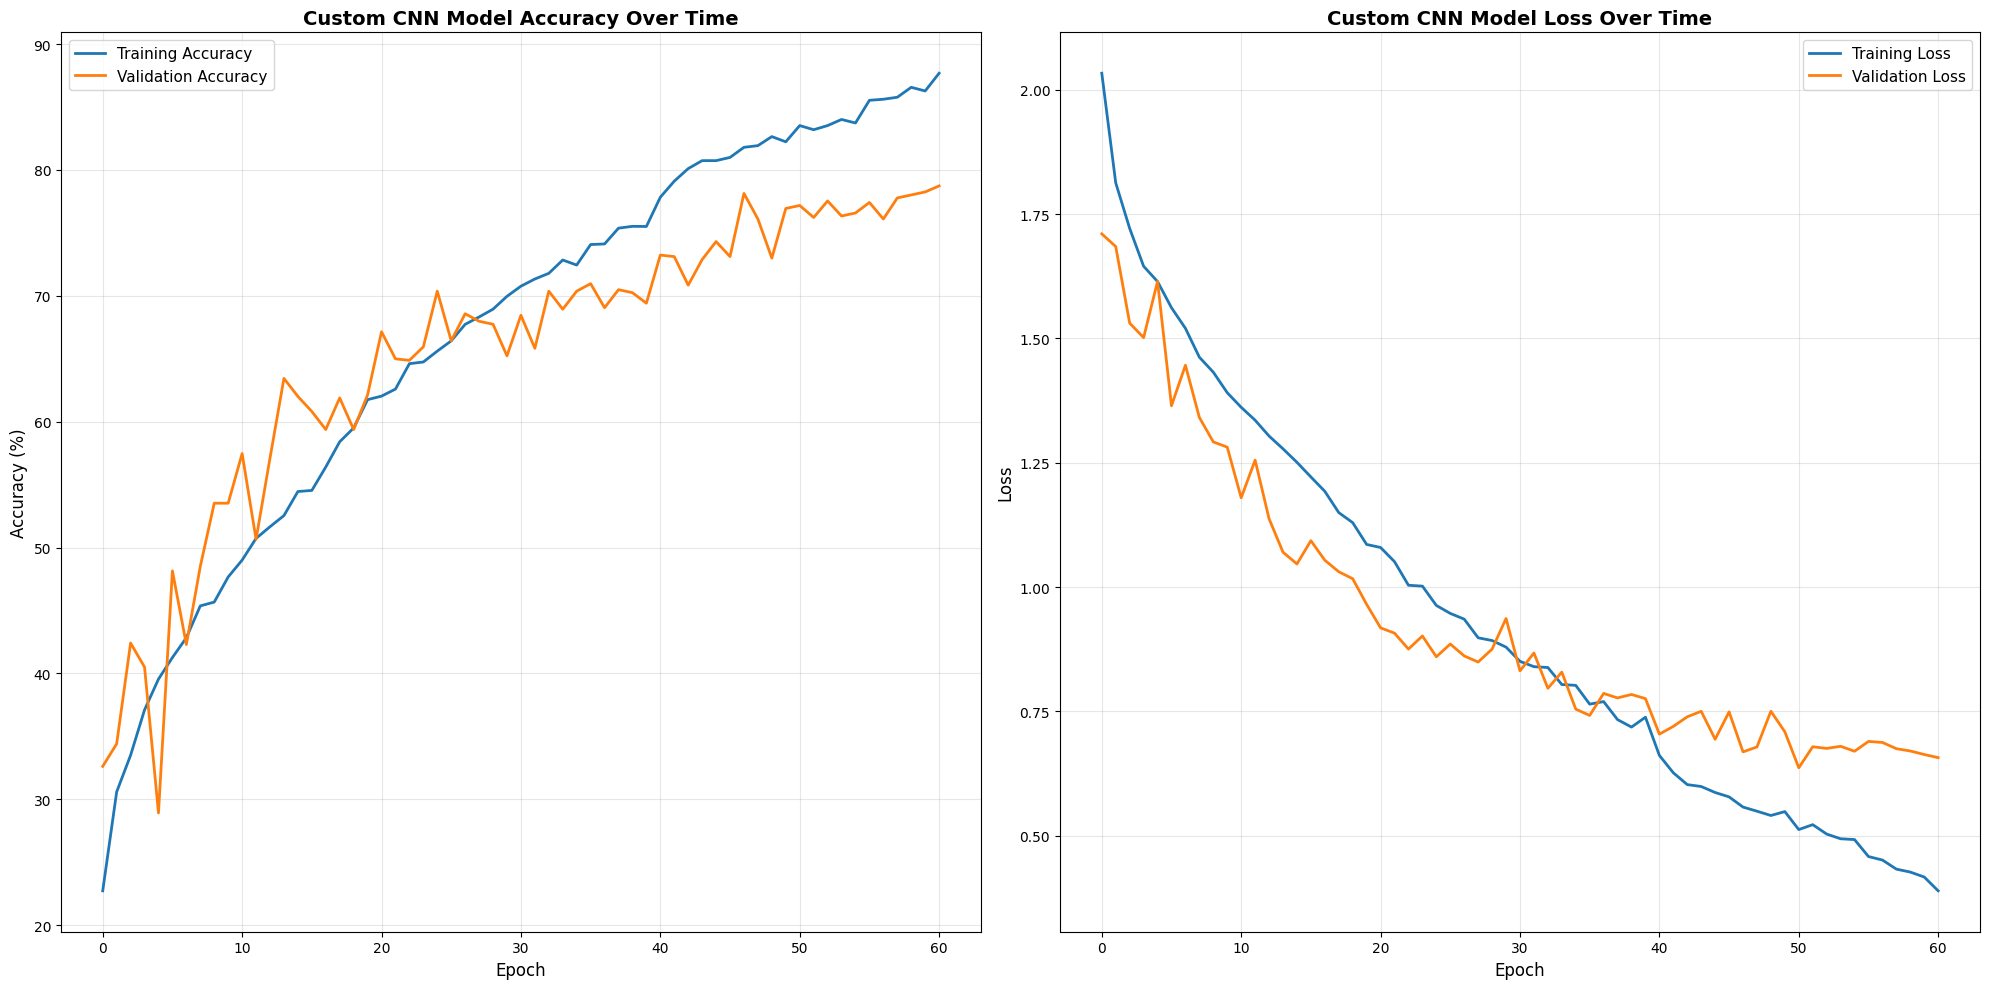

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot accuracy
axes[0].plot(history_custom_cnn['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_custom_cnn['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Custom CNN Model Accuracy Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history_custom_cnn['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_custom_cnn['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Custom CNN Model Loss Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Inception Model

In [9]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn

# Note: Assumes EarlyStopping class is already defined in your environment



# ============================================
# PREPARE DATA LOADERS
# ============================================
print("\n" + "=" * 60)
print("PREPARING DATA LOADERS")
print("=" * 60)

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
y_val_tensor = torch.LongTensor(y_val)

print(f"Training tensor shape: {X_train_tensor.shape}")
print(f"Training labels shape: {y_train_tensor.shape}")
print(f"Validation tensor shape: {X_val_tensor.shape}")
print(f"Validation labels shape: {y_val_tensor.shape}")

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\n✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(val_loader)}")

# ============================================
# TRAINING CONFIGURATION
# ============================================
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)

num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inception_v3_model = inception_v3_model.to(device)

print(f"Training on device: {device}")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"Number of epochs: {num_epochs}")

# Initialize history dictionary (like Keras)
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []  # Track learning rate changes
}

# ============================================
# TRAINING LOOP
# ============================================
for epoch in range(num_epochs):
    # ========================================
    # TRAINING PHASE
    # ========================================
    inception_v3_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        
        # InceptionV3 returns auxiliary outputs during training
        if inception_v3_model.training:
            outputs = inception_v3_model(inputs)
            # Check if auxiliary outputs are returned
            if isinstance(outputs, tuple):
                main_output, aux_output = outputs
                # Compute combined loss (main + 0.4 * auxiliary)
                loss1 = criterion(main_output, labels)
                loss2 = criterion(aux_output, labels)
                loss = loss1 + 0.4 * loss2
                outputs = main_output  # Use main output for accuracy
            else:
                loss = criterion(outputs, labels)
        else:
            outputs = inception_v3_model(inputs)
            loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = 100 * train_correct / train_total
    
    # ========================================
    # VALIDATION PHASE
    # ========================================
    inception_v3_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = inception_v3_model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = 100 * val_correct / val_total
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Print progress
    print(f'Epoch {epoch+1}/{num_epochs} - '
          f'loss: {train_loss:.4f} - accuracy: {train_acc:.2f}% - '
          f'val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.2f}% - '
          f'lr: {current_lr:.2e}')
    
    # Step the learning rate scheduler
    old_lr = current_lr
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    # Print if learning rate changed
    if old_lr != new_lr:
        print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')
    
    # Check early stopping
    early_stopping(val_loss, inception_v3_model)
    
    if early_stopping.early_stop:
        print("Early stopping triggered!")
        early_stopping.load_best_weights(inception_v3_model)
        break

# If training completed without early stopping, load best weights anyway
if not early_stopping.early_stop:
    early_stopping.load_best_weights(inception_v3_model)

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)
print(f"Best validation loss: {early_stopping.val_loss_min:.4f}")
print(f"Total epochs trained: {len(history['loss'])}")

# Store as history_inception_v3 (like Keras History object)
history_inception_v3 = history

# ============================================
# SAVE THE TRAINED MODEL
# ============================================
print("\n" + "=" * 60)
print("SAVING MODEL")
print("=" * 60)

# Save the model
torch.save(inception_v3_model.state_dict(), 'inception_v3_trained.pth')
print("✓ Model saved to 'inception_v3_trained.pth'")

# Save training history
import pickle
with open('history_inception_v3.pkl', 'wb') as f:
    pickle.dump(history_inception_v3, f)
print("✓ Training history saved to 'history_inception_v3.pkl'")

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)
print(f"Best validation loss: {early_stopping.val_loss_min:.4f}")
print(f"Total epochs trained: {len(history['loss'])}")


PREPARING DATA LOADERS
Training tensor shape: torch.Size([8220, 1, 128, 173])
Training labels shape: torch.Size([8220])
Validation tensor shape: torch.Size([837, 1, 128, 173])
Validation labels shape: torch.Size([837])

✓ Training batches: 257
✓ Validation batches: 27

STARTING TRAINING
Training on device: cuda
Initial learning rate: 1.00e-03
Number of epochs: 100
Epoch 1/100 - loss: 1.0781 - accuracy: 74.44% - val_loss: 1.0307 - val_accuracy: 67.03% - lr: 1.00e-03
Validation loss decreased (inf --> 1.030704). Saving model to best_model_fold1.pth
Epoch 2/100 - loss: 0.5357 - accuracy: 87.57% - val_loss: 0.7581 - val_accuracy: 81.12% - lr: 1.00e-03
Validation loss decreased (1.030704 --> 0.758084). Saving model to best_model_fold1.pth
Epoch 3/100 - loss: 0.3826 - accuracy: 91.14% - val_loss: 0.6333 - val_accuracy: 82.68% - lr: 1.00e-03
Validation loss decreased (0.758084 --> 0.633339). Saving model to best_model_fold1.pth
Epoch 4/100 - loss: 0.2949 - accuracy: 93.20% - val_loss: 0.8803

Evaluation

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("\nFINAL EVALUATION - INCEPTION V3")
print("=" * 60)

def evaluate_model(model, X, y, device):
    """Evaluate model on given data"""
    model.eval()
    
    # Convert to tensors and permute dimensions
    # From (samples, height, width, channels) to (samples, channels, height, width)
    if not isinstance(X, torch.Tensor):
        X = torch.FloatTensor(X)
    if not isinstance(y, torch.Tensor):
        y = torch.LongTensor(y)
    
    # Permute from (batch, 128, 173, 1) to (batch, 1, 128, 173)
    if X.dim() == 4 and X.shape[-1] == 1:
        X = X.permute(0, 3, 1, 2)  # Now (batch, 1, 128, 173)
    
    # Create dataset and dataloader
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    total_loss = 0
    correct = 0
    total = 0
    
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    
    return avg_loss, accuracy

# Get device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Validation evaluation
inception_v3_val_loss, inception_v3_val_accuracy = evaluate_model(inception_v3_model, X_val, y_val, device)

# Test evaluation  
inception_v3_test_loss, inception_v3_test_accuracy = evaluate_model(inception_v3_model, X_test, y_test, device)

print(f"Final Validation Loss: {inception_v3_val_loss:.4f}")
print(f"Final Validation Accuracy: {inception_v3_val_accuracy:.4f} ({inception_v3_val_accuracy*100:.2f}%)")
print()
print(f"Final Test Loss: {inception_v3_test_loss:.4f}")
print(f"Final Test Accuracy: {inception_v3_test_accuracy:.4f} ({inception_v3_test_accuracy*100:.2f}%)")
print("=" * 60)


FINAL EVALUATION - INCEPTION V3
Final Validation Loss: 0.6053
Final Validation Accuracy: 0.8674 (86.74%)

Final Test Loss: 0.8439
Final Test Accuracy: 0.8578 (85.78%)


Plot training history

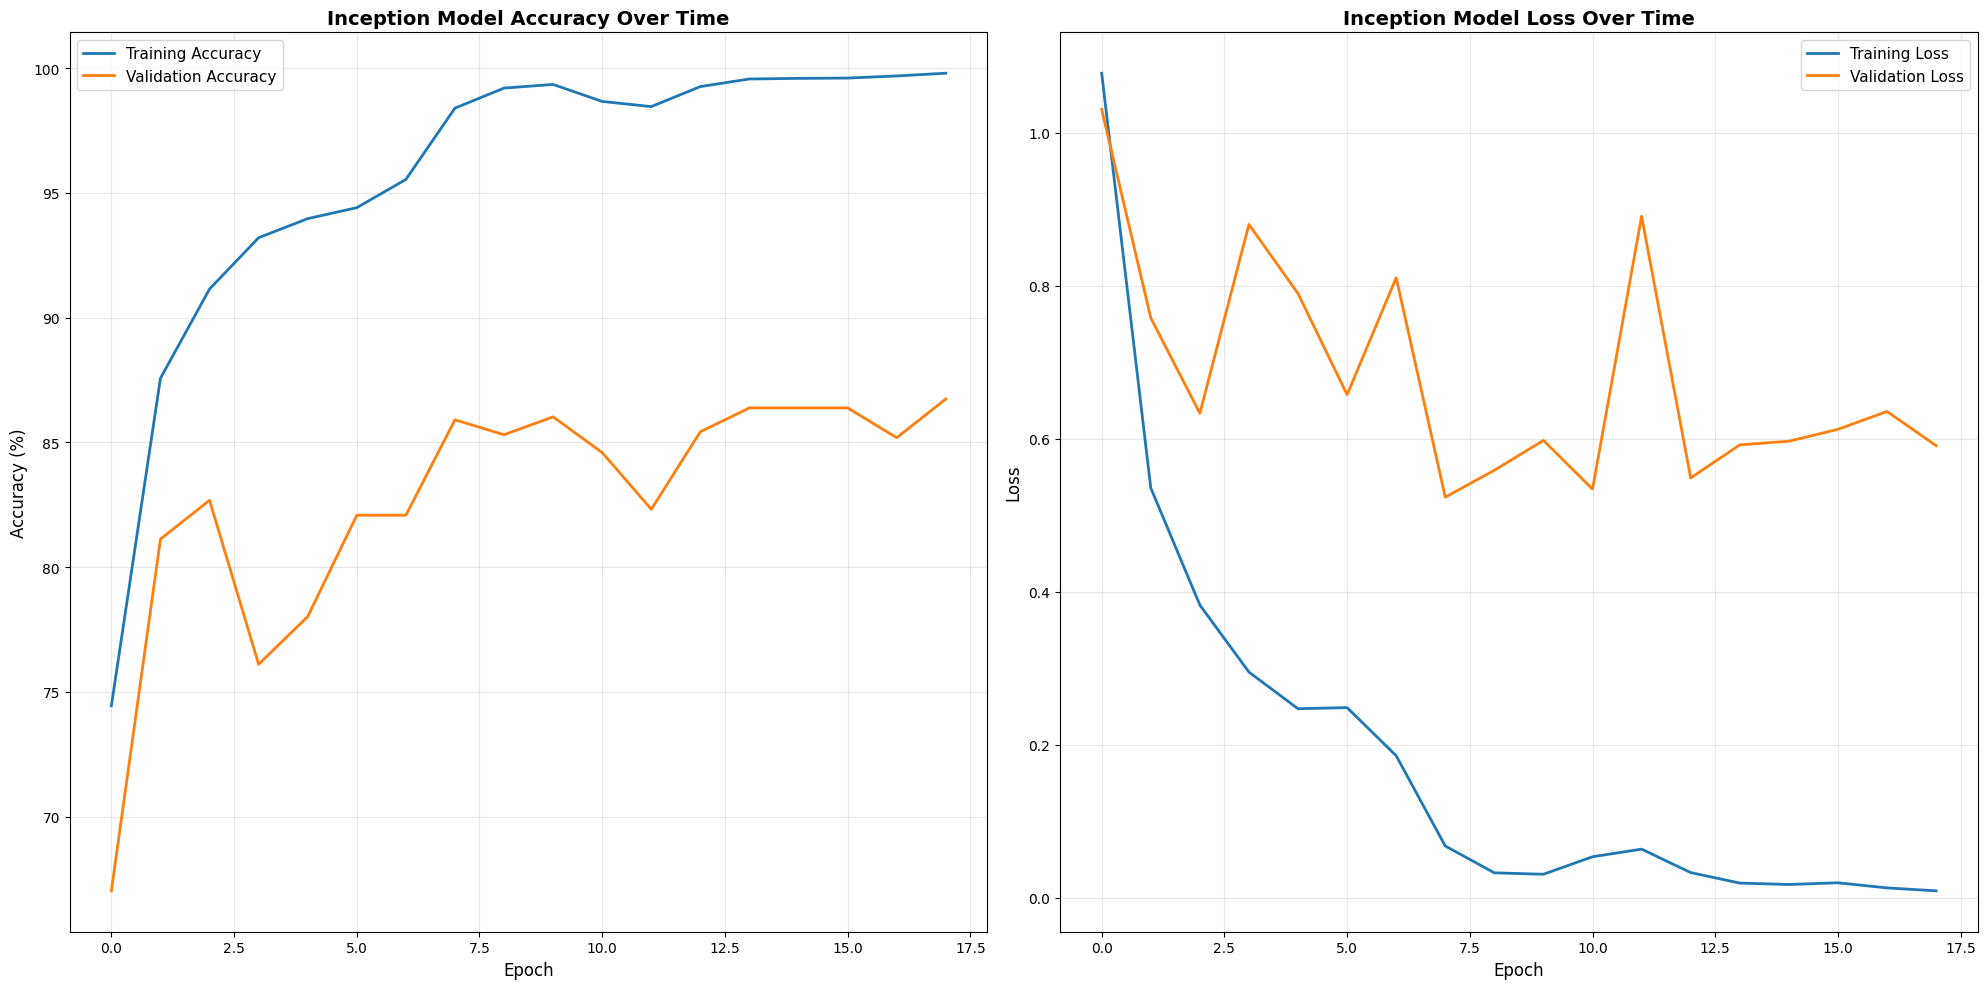

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot accuracy
axes[0].plot(history_inception_v3['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_inception_v3['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Inception Model Accuracy Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history_inception_v3['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_inception_v3['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Inception Model Loss Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

-----------------------------------------------------------
-----------------------------------------------------------

// Try somethings with deepfool

----------------------------------------------------
--------------------------------------------------------

# **Observations and conclusions**

Some observations on the results of the custom CNN and the inception model

### Custom CNN Model

- **Confusion Matrix**

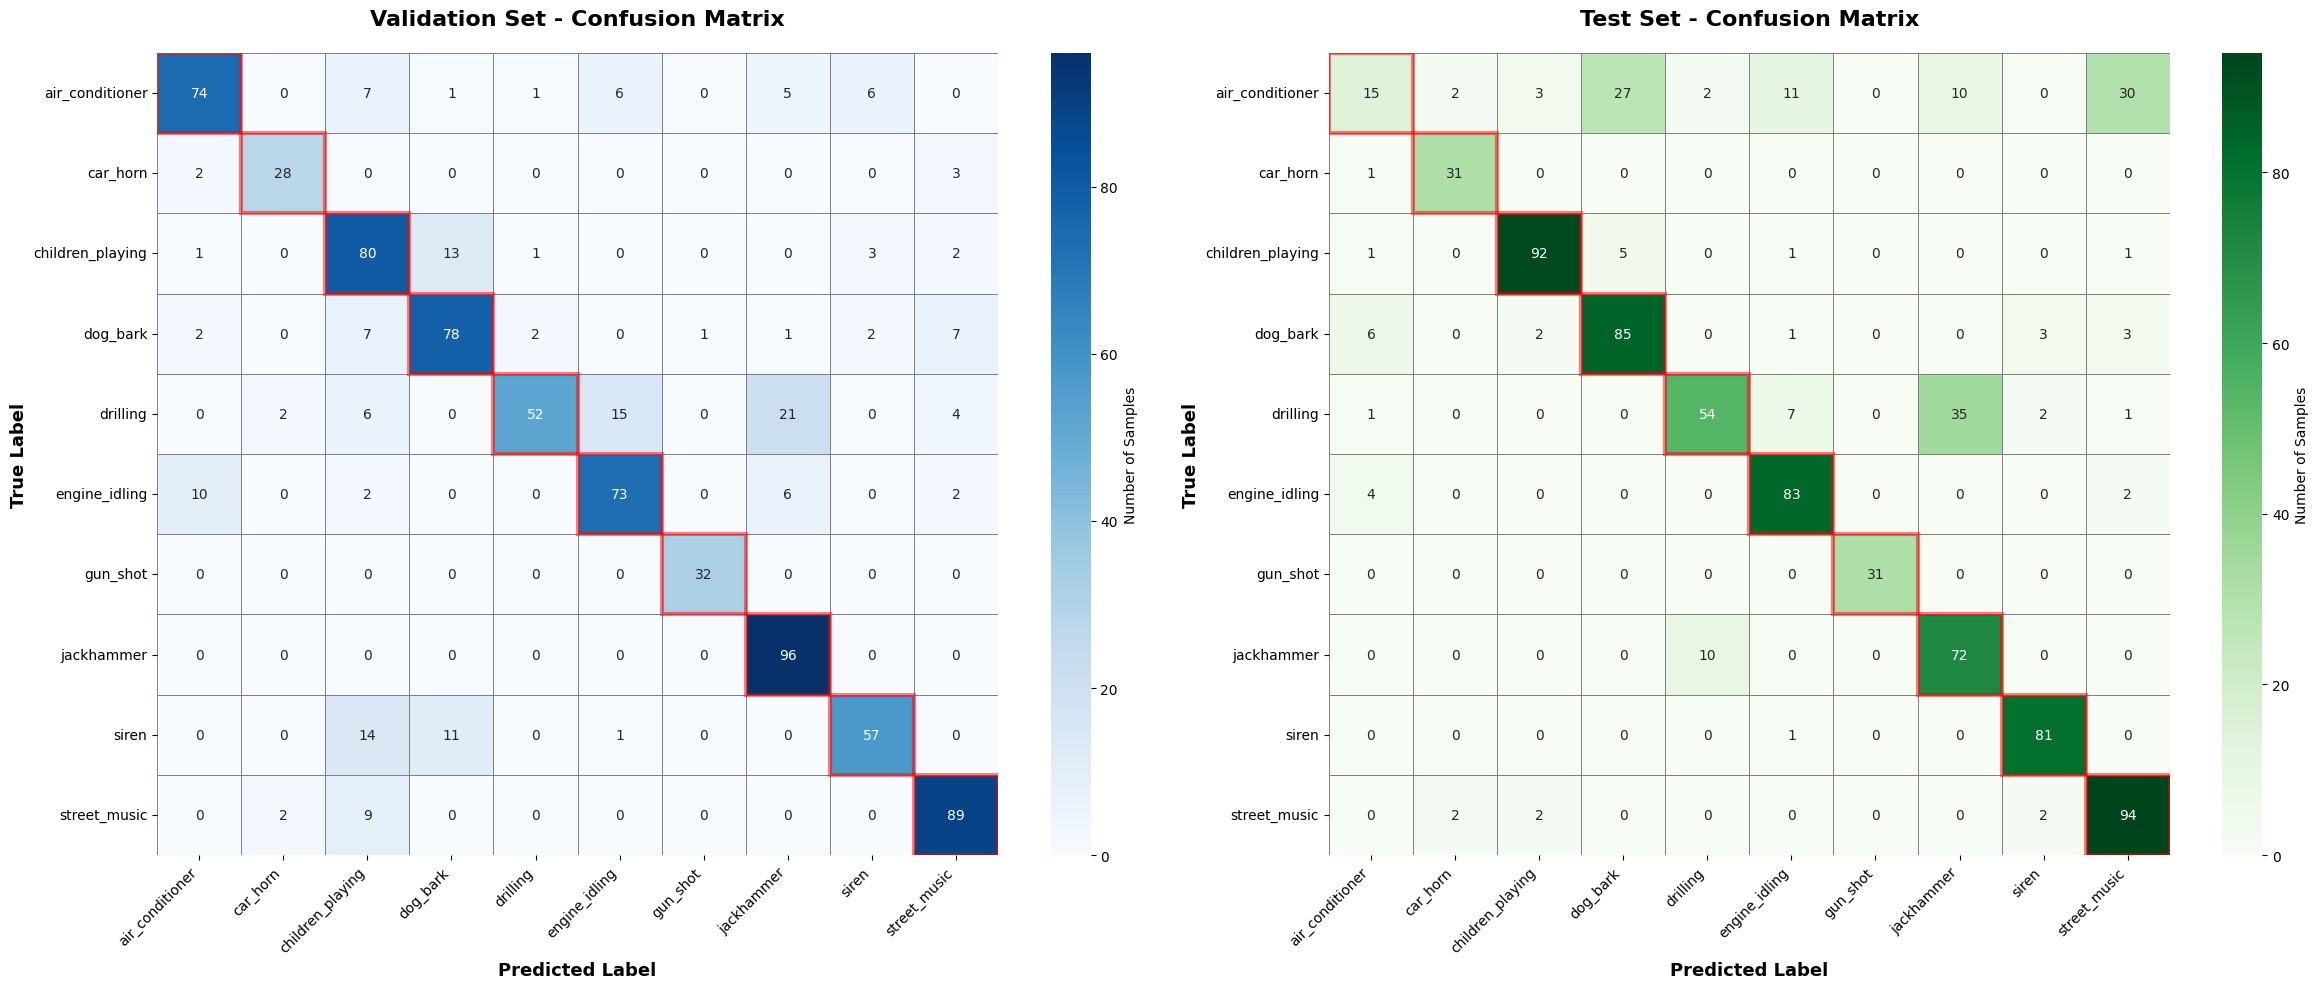

Validation Accuracy: 78.73%
Test Accuracy: 78.19%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import torch

# Set model to evaluation mode
custom_cnn.eval()

# Function to get predictions
def get_predictions(X_data, model, device, batch_size=32):
    y_pred_list = []
    with torch.no_grad():
        # Convert data to tensor if not already
        if not isinstance(X_data, torch.Tensor):
            X_tensor = torch.FloatTensor(X_data).permute(0, 3, 1, 2)
        else:
            X_tensor = X_data
        
        # Move to device
        X_tensor = X_tensor.to(device)
        
        # Get predictions in batches to avoid memory issues
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            outputs = model(batch)
            _, predicted = torch.max(outputs, 1)
            y_pred_list.extend(predicted.cpu().numpy())
    
    return np.array(y_pred_list)

# Get predictions for validation set
y_pred_val = get_predictions(X_val, custom_cnn, device)

# Get predictions for test set
y_pred_test = get_predictions(X_test, custom_cnn, device)

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Create confusion matrices
cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot validation confusion matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            linewidths=0.5,
            linecolor='gray',
            ax=axes[0])

axes[0].set_title('Validation Set - Confusion Matrix', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names, rotation=0)

# Highlight diagonal for validation
for i in range(len(class_names)):
    axes[0].add_patch(plt.Rectangle((i, i), 1, 1, 
                                    fill=False, edgecolor='red', 
                                    lw=3, alpha=0.5))

# Plot test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            linewidths=0.5,
            linecolor='gray',
            ax=axes[1])

axes[1].set_title('Test Set - Confusion Matrix', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names, rotation=0)

# Highlight diagonal for test
for i in range(len(class_names)):
    axes[1].add_patch(plt.Rectangle((i, i), 1, 1, 
                                    fill=False, edgecolor='red', 
                                    lw=3, alpha=0.5))

plt.tight_layout()
plt.show()

# Optional: Print accuracy for both sets
val_accuracy = np.trace(cm_val) / np.sum(cm_val) * 100
test_accuracy = np.trace(cm_test) / np.sum(cm_test) * 100

print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

- **Most confused class pairs**

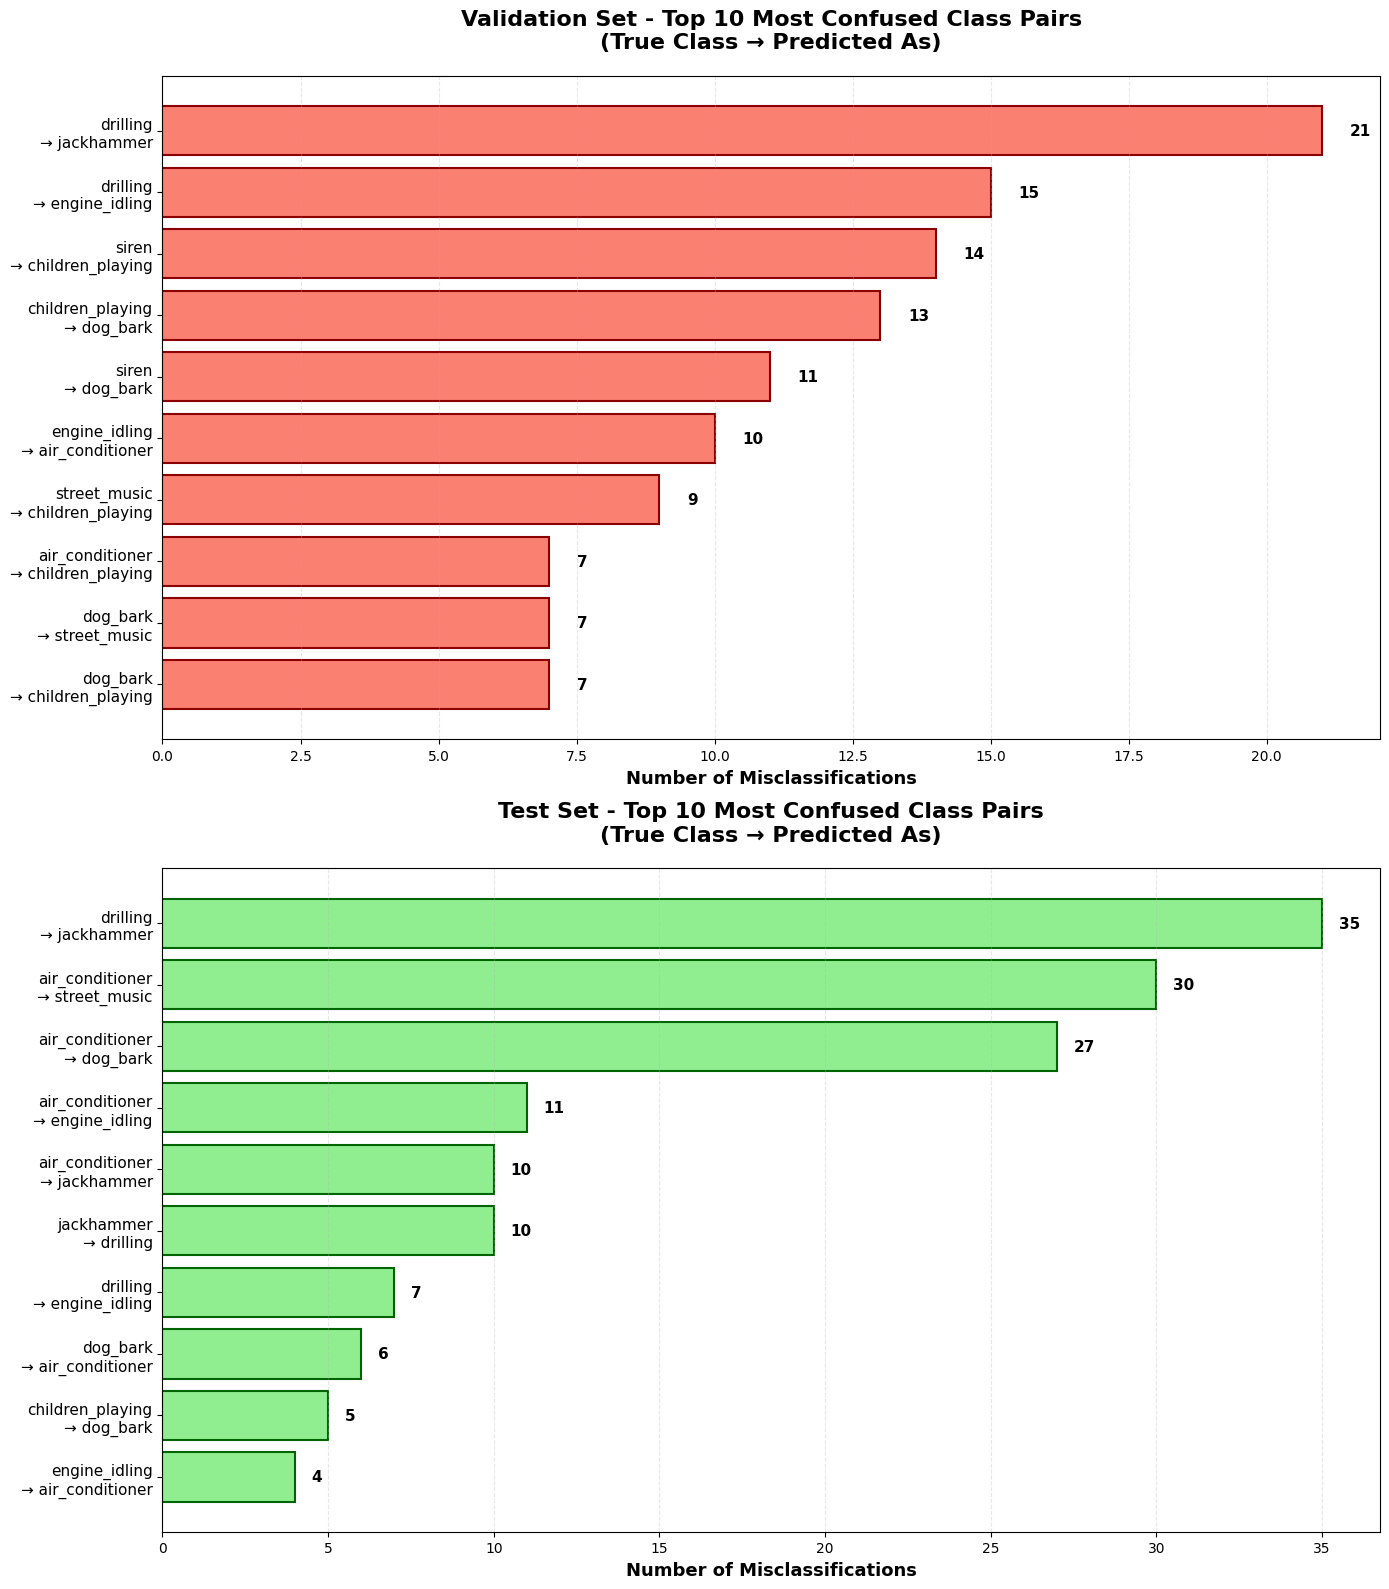

In [13]:
# Function to analyze confused pairs
def analyze_confused_pairs(cm, class_names):
    confused_pairs = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i, j] > 0:
                confused_pairs.append({
                    'true_class': class_names[i],
                    'predicted_as': class_names[j],
                    'count': cm[i, j]
                })
    
    confused_df = pd.DataFrame(confused_pairs)
    confused_df = confused_df.sort_values('count', ascending=False)
    return confused_df

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Analyze both validation and test sets
confused_df_val = analyze_confused_pairs(cm_val, class_names)
confused_df_test = analyze_confused_pairs(cm_test, class_names)

# Create figure with two subplots (validation on top, test on bottom)
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Plot validation set (top)
top_n_val = min(10, len(confused_df_val))
top_confused_val = confused_df_val.head(top_n_val)

bars_val = axes[0].barh(range(top_n_val), top_confused_val['count'].values, 
                        color='salmon', edgecolor='darkred', linewidth=1.5)

labels_val = [f"{row['true_class']}\n→ {row['predicted_as']}" 
              for _, row in top_confused_val.iterrows()]
axes[0].set_yticks(range(top_n_val))
axes[0].set_yticklabels(labels_val, fontsize=11)

for i, (idx, row) in enumerate(top_confused_val.iterrows()):
    axes[0].text(row['count'] + 0.5, i, f"{int(row['count'])}", 
                 va='center', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Number of Misclassifications', fontsize=13, fontweight='bold')
axes[0].set_title('Validation Set - Top 10 Most Confused Class Pairs\n(True Class → Predicted As)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()

# Plot test set (bottom)
top_n_test = min(10, len(confused_df_test))
top_confused_test = confused_df_test.head(top_n_test)

bars_test = axes[1].barh(range(top_n_test), top_confused_test['count'].values, 
                         color='lightgreen', edgecolor='darkgreen', linewidth=1.5)

labels_test = [f"{row['true_class']}\n→ {row['predicted_as']}" 
               for _, row in top_confused_test.iterrows()]
axes[1].set_yticks(range(top_n_test))
axes[1].set_yticklabels(labels_test, fontsize=11)

for i, (idx, row) in enumerate(top_confused_test.iterrows()):
    axes[1].text(row['count'] + 0.5, i, f"{int(row['count'])}", 
                 va='center', fontsize=11, fontweight='bold')

axes[1].set_xlabel('Number of Misclassifications', fontsize=13, fontweight='bold')
axes[1].set_title('Test Set - Top 10 Most Confused Class Pairs\n(True Class → Predicted As)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


- **Error Analysis per class**

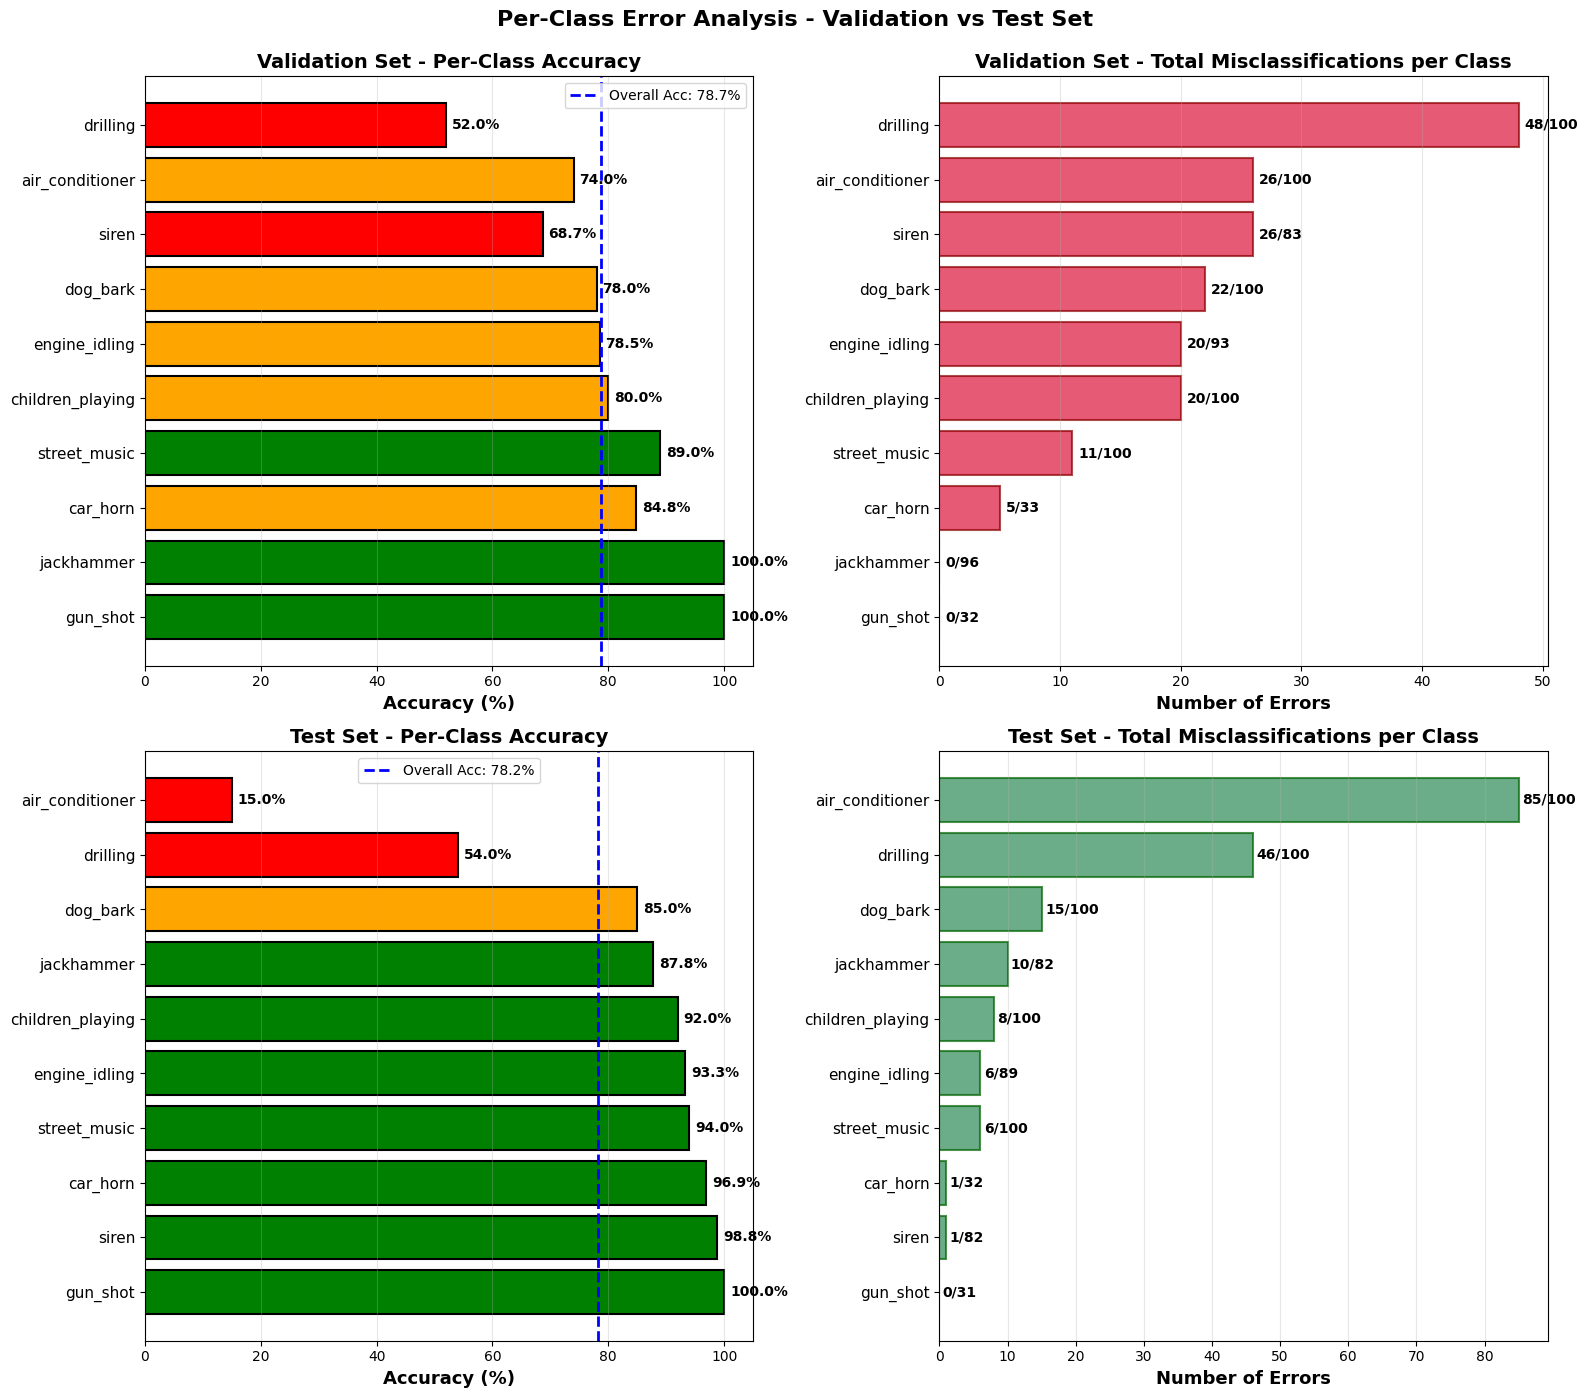


VALIDATION SET - Per-Class Statistics:
           Class  Total  Correct  Errors  Accuracy
        drilling    100       52      48  0.520000
 air_conditioner    100       74      26  0.740000
           siren     83       57      26  0.686747
        dog_bark    100       78      22  0.780000
   engine_idling     93       73      20  0.784946
children_playing    100       80      20  0.800000
    street_music    100       89      11  0.890000
        car_horn     33       28       5  0.848485
      jackhammer     96       96       0  1.000000
        gun_shot     32       32       0  1.000000

TEST SET - Per-Class Statistics:
           Class  Total  Correct  Errors  Accuracy
 air_conditioner    100       15      85  0.150000
        drilling    100       54      46  0.540000
        dog_bark    100       85      15  0.850000
      jackhammer     82       72      10  0.878049
children_playing    100       92       8  0.920000
   engine_idling     89       83       6  0.932584
    stre

In [14]:
# Function to calculate per-class metrics
def calculate_class_metrics(cm, class_names):
    class_correct = cm.diagonal()
    class_total = cm.sum(axis=1)
    class_errors = class_total - class_correct
    class_accuracy = class_correct / class_total
    
    error_analysis = pd.DataFrame({
        'Class': class_names,
        'Total': class_total,
        'Correct': class_correct,
        'Errors': class_errors,
        'Accuracy': class_accuracy
    })
    error_analysis = error_analysis.sort_values('Errors', ascending=False)
    return error_analysis

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Calculate metrics for both sets
error_analysis_val = calculate_class_metrics(cm_val, class_names)
error_analysis_test = calculate_class_metrics(cm_test, class_names)

# Calculate overall accuracies
val_overall_accuracy = np.trace(cm_val) / np.sum(cm_val)
test_overall_accuracy = np.trace(cm_test) / np.sum(cm_test)

# Create figure with 2 rows (validation top, test bottom)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ============= VALIDATION SET (Top Row) =============

# Validation - Accuracy by class
colors_val = ['green' if acc > 0.85 else 'orange' if acc > 0.70 else 'red' 
              for acc in error_analysis_val['Accuracy']]
axes[0, 0].barh(range(len(error_analysis_val)), 
                error_analysis_val['Accuracy'] * 100, 
                color=colors_val, edgecolor='black', linewidth=1.5)
axes[0, 0].set_yticks(range(len(error_analysis_val)))
axes[0, 0].set_yticklabels(error_analysis_val['Class'], fontsize=11)
axes[0, 0].set_xlabel('Accuracy (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Validation Set - Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=val_overall_accuracy*100, color='blue', linestyle='--', 
                   linewidth=2, label=f'Overall Acc: {val_overall_accuracy*100:.1f}%')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_val.iterrows()):
    axes[0, 0].text(row['Accuracy'] * 100 + 1, i, 
                    f"{row['Accuracy']*100:.1f}%", 
                    va='center', fontsize=10, fontweight='bold')

# Validation - Number of errors by class
axes[0, 1].barh(range(len(error_analysis_val)), 
                error_analysis_val['Errors'], 
                color='crimson', edgecolor='darkred', linewidth=1.5, alpha=0.7)
axes[0, 1].set_yticks(range(len(error_analysis_val)))
axes[0, 1].set_yticklabels(error_analysis_val['Class'], fontsize=11)
axes[0, 1].set_xlabel('Number of Errors', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Validation Set - Total Misclassifications per Class', 
                     fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_val.iterrows()):
    axes[0, 1].text(row['Errors'] + 0.5, i, 
                    f"{int(row['Errors'])}/{int(row['Total'])}", 
                    va='center', fontsize=10, fontweight='bold')

# ============= TEST SET (Bottom Row) =============

# Test - Accuracy by class
colors_test = ['green' if acc > 0.85 else 'orange' if acc > 0.70 else 'red' 
               for acc in error_analysis_test['Accuracy']]
axes[1, 0].barh(range(len(error_analysis_test)), 
                error_analysis_test['Accuracy'] * 100, 
                color=colors_test, edgecolor='black', linewidth=1.5)
axes[1, 0].set_yticks(range(len(error_analysis_test)))
axes[1, 0].set_yticklabels(error_analysis_test['Class'], fontsize=11)
axes[1, 0].set_xlabel('Accuracy (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Test Set - Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=test_overall_accuracy*100, color='blue', linestyle='--', 
                   linewidth=2, label=f'Overall Acc: {test_overall_accuracy*100:.1f}%')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_test.iterrows()):
    axes[1, 0].text(row['Accuracy'] * 100 + 1, i, 
                    f"{row['Accuracy']*100:.1f}%", 
                    va='center', fontsize=10, fontweight='bold')

# Test - Number of errors by class
axes[1, 1].barh(range(len(error_analysis_test)), 
                error_analysis_test['Errors'], 
                color='seagreen', edgecolor='darkgreen', linewidth=1.5, alpha=0.7)
axes[1, 1].set_yticks(range(len(error_analysis_test)))
axes[1, 1].set_yticklabels(error_analysis_test['Class'], fontsize=11)
axes[1, 1].set_xlabel('Number of Errors', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Test Set - Total Misclassifications per Class', 
                     fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_test.iterrows()):
    axes[1, 1].text(row['Errors'] + 0.5, i, 
                    f"{int(row['Errors'])}/{int(row['Total'])}", 
                    va='center', fontsize=10, fontweight='bold')

plt.suptitle('Per-Class Error Analysis - Validation vs Test Set', 
             fontsize=16, fontweight='bold', y=0.995)
             
plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("VALIDATION SET - Per-Class Statistics:")
print("="*70)
print(error_analysis_val.to_string(index=False))

print("\n" + "="*70)
print("TEST SET - Per-Class Statistics:")
print("="*70)
print(error_analysis_test.to_string(index=False))

### Inception model 

- **Confusion Matrix**

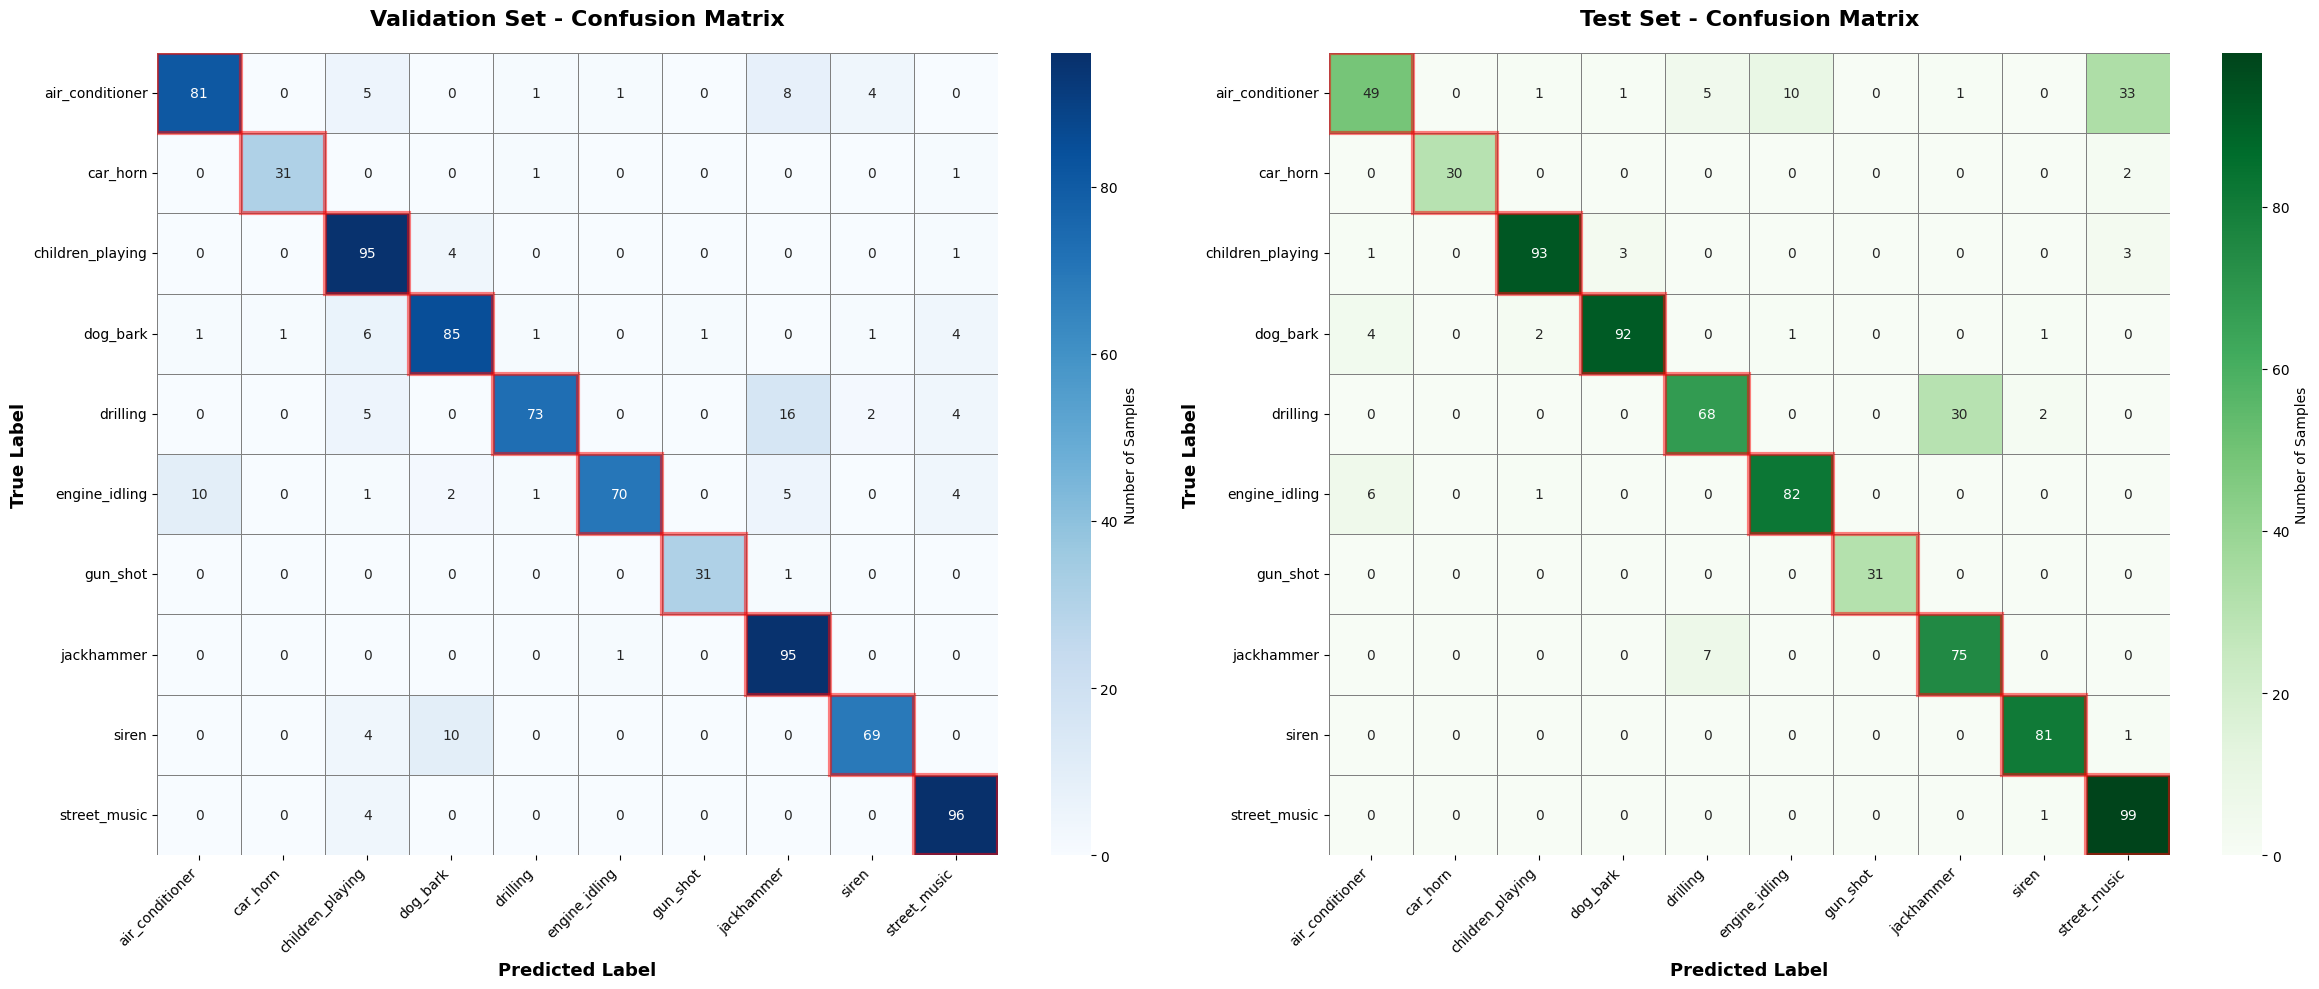

Validation Accuracy: 86.74%
Test Accuracy: 85.78%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import torch

# Set model to evaluation mode
inception_v3_model.eval()

# Function to get predictions
def get_predictions(X_data, model, device, batch_size=32):
    y_pred_list = []
    with torch.no_grad():
        # Convert data to tensor if not already
        if not isinstance(X_data, torch.Tensor):
            X_tensor = torch.FloatTensor(X_data).permute(0, 3, 1, 2)
        else:
            X_tensor = X_data
        
        # Move to device
        X_tensor = X_tensor.to(device)
        
        # Get predictions in batches to avoid memory issues
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            outputs = model(batch)
            _, predicted = torch.max(outputs, 1)
            y_pred_list.extend(predicted.cpu().numpy())
    
    return np.array(y_pred_list)

# Get predictions for validation set
y_pred_val = get_predictions(X_val, inception_v3_model, device)

# Get predictions for test set
y_pred_test = get_predictions(X_test, inception_v3_model, device)

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Create confusion matrices
ic_val = confusion_matrix(y_val, y_pred_val)
ic_test = confusion_matrix(y_test, y_pred_test)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot validation confusion matrix
sns.heatmap(ic_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            linewidths=0.5,
            linecolor='gray',
            ax=axes[0])

axes[0].set_title('Validation Set - Confusion Matrix', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names, rotation=0)

# Highlight diagonal for validation
for i in range(len(class_names)):
    axes[0].add_patch(plt.Rectangle((i, i), 1, 1, 
                                    fill=False, edgecolor='red', 
                                    lw=3, alpha=0.5))

# Plot test confusion matrix
sns.heatmap(ic_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            linewidths=0.5,
            linecolor='gray',
            ax=axes[1])

axes[1].set_title('Test Set - Confusion Matrix', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_yticklabels(class_names, rotation=0)

# Highlight diagonal for test
for i in range(len(class_names)):
    axes[1].add_patch(plt.Rectangle((i, i), 1, 1, 
                                    fill=False, edgecolor='red', 
                                    lw=3, alpha=0.5))

plt.tight_layout()
plt.show()

# Optional: Print accuracy for both sets
inception_val_accuracy = np.trace(ic_val) / np.sum(ic_val) * 100
inception_test_accuracy = np.trace(ic_test) / np.sum(ic_test) * 100

print(f"Validation Accuracy: {inception_val_accuracy:.2f}%")
print(f"Test Accuracy: {inception_test_accuracy:.2f}%")

- **Most confused class pairs**

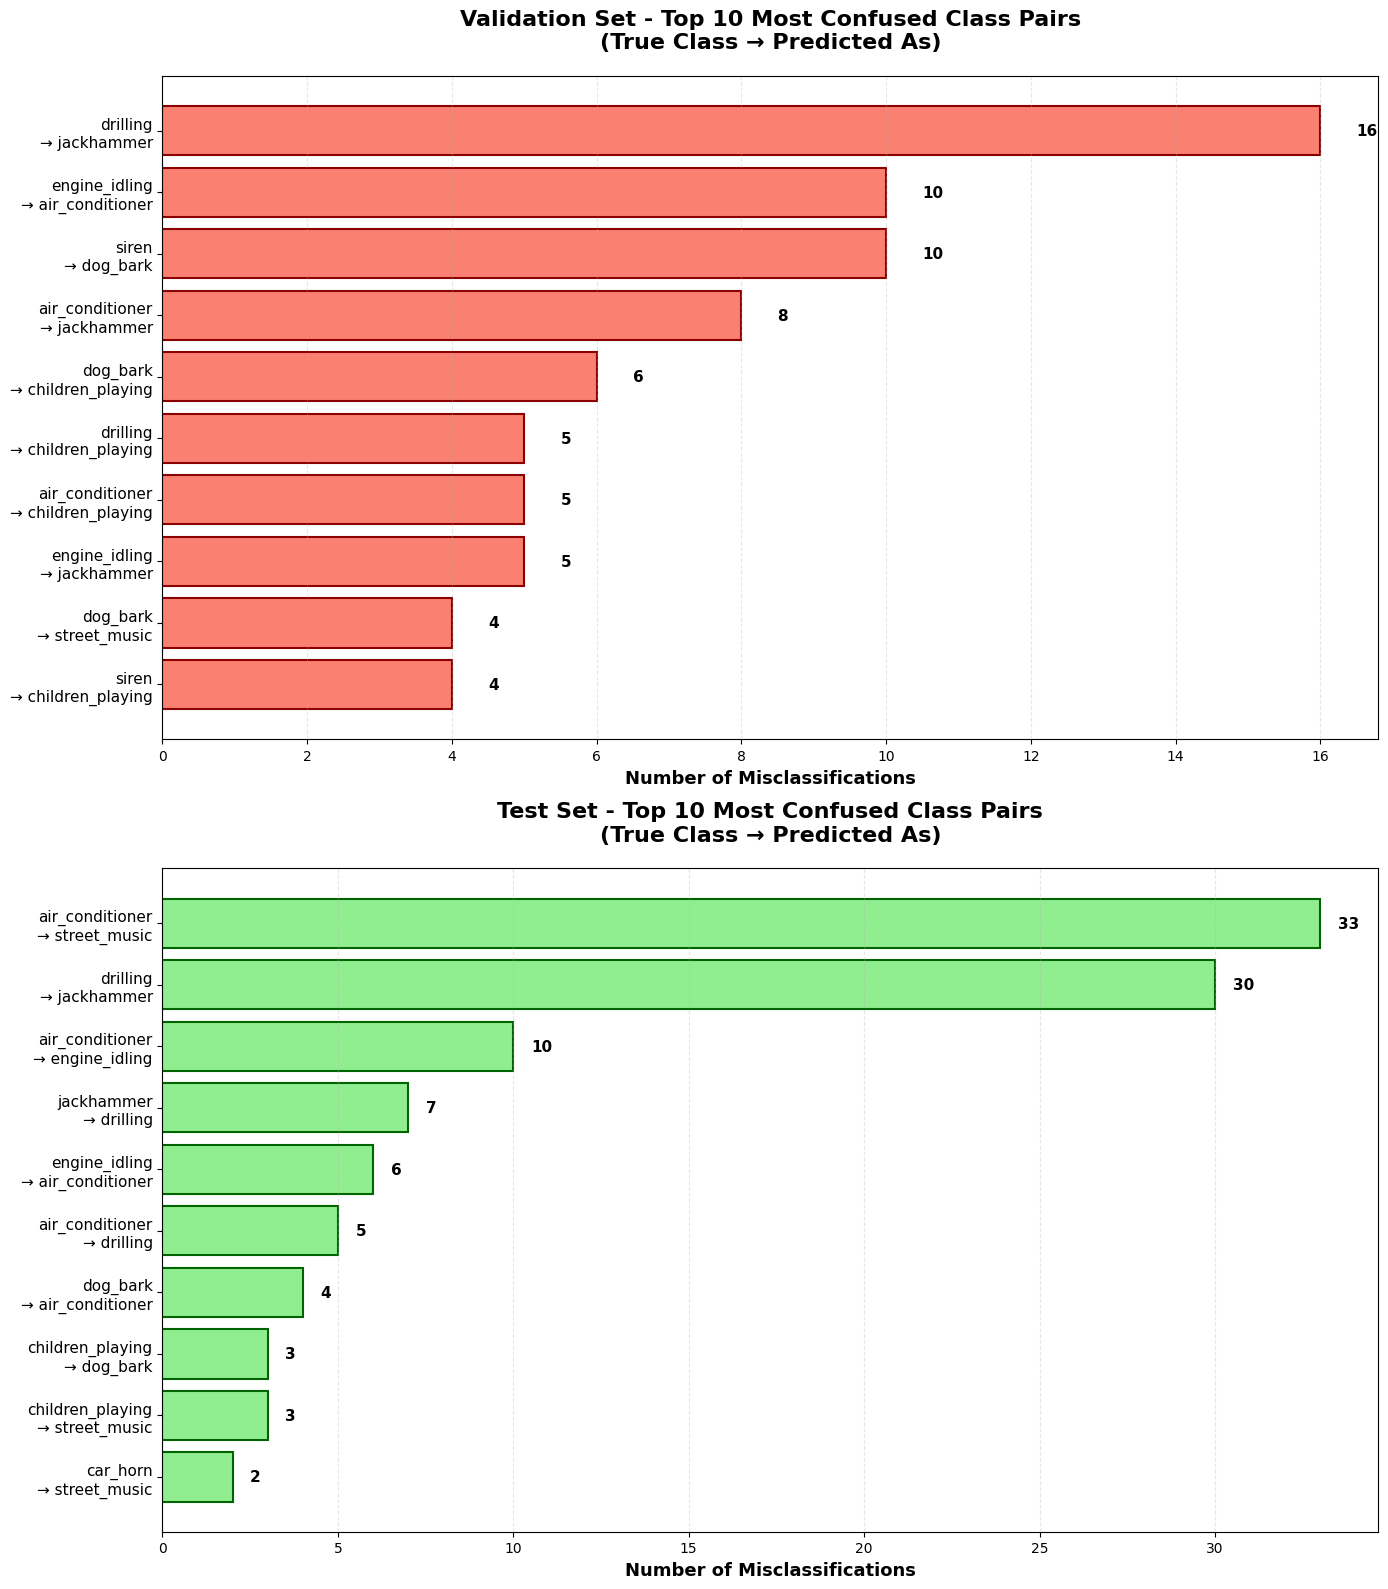

In [13]:
# Function to analyze confused pairs
def analyze_confused_pairs(cm, class_names):
    confused_pairs = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i, j] > 0:
                confused_pairs.append({
                    'true_class': class_names[i],
                    'predicted_as': class_names[j],
                    'count': cm[i, j]
                })
    
    confused_df = pd.DataFrame(confused_pairs)
    confused_df = confused_df.sort_values('count', ascending=False)
    return confused_df

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Analyze both validation and test sets
confused_df_val = analyze_confused_pairs(ic_val, class_names)
confused_df_test = analyze_confused_pairs(ic_test, class_names)

# Create figure with two subplots (validation on top, test on bottom)
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Plot validation set (top)
top_n_val = min(10, len(confused_df_val))
top_confused_val = confused_df_val.head(top_n_val)

bars_val = axes[0].barh(range(top_n_val), top_confused_val['count'].values, 
                        color='salmon', edgecolor='darkred', linewidth=1.5)

labels_val = [f"{row['true_class']}\n→ {row['predicted_as']}" 
              for _, row in top_confused_val.iterrows()]
axes[0].set_yticks(range(top_n_val))
axes[0].set_yticklabels(labels_val, fontsize=11)

for i, (idx, row) in enumerate(top_confused_val.iterrows()):
    axes[0].text(row['count'] + 0.5, i, f"{int(row['count'])}", 
                 va='center', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Number of Misclassifications', fontsize=13, fontweight='bold')
axes[0].set_title('Validation Set - Top 10 Most Confused Class Pairs\n(True Class → Predicted As)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()

# Plot test set (bottom)
top_n_test = min(10, len(confused_df_test))
top_confused_test = confused_df_test.head(top_n_test)

bars_test = axes[1].barh(range(top_n_test), top_confused_test['count'].values, 
                         color='lightgreen', edgecolor='darkgreen', linewidth=1.5)

labels_test = [f"{row['true_class']}\n→ {row['predicted_as']}" 
               for _, row in top_confused_test.iterrows()]
axes[1].set_yticks(range(top_n_test))
axes[1].set_yticklabels(labels_test, fontsize=11)

for i, (idx, row) in enumerate(top_confused_test.iterrows()):
    axes[1].text(row['count'] + 0.5, i, f"{int(row['count'])}", 
                 va='center', fontsize=11, fontweight='bold')

axes[1].set_xlabel('Number of Misclassifications', fontsize=13, fontweight='bold')
axes[1].set_title('Test Set - Top 10 Most Confused Class Pairs\n(True Class → Predicted As)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


- **Error Analysis per class**

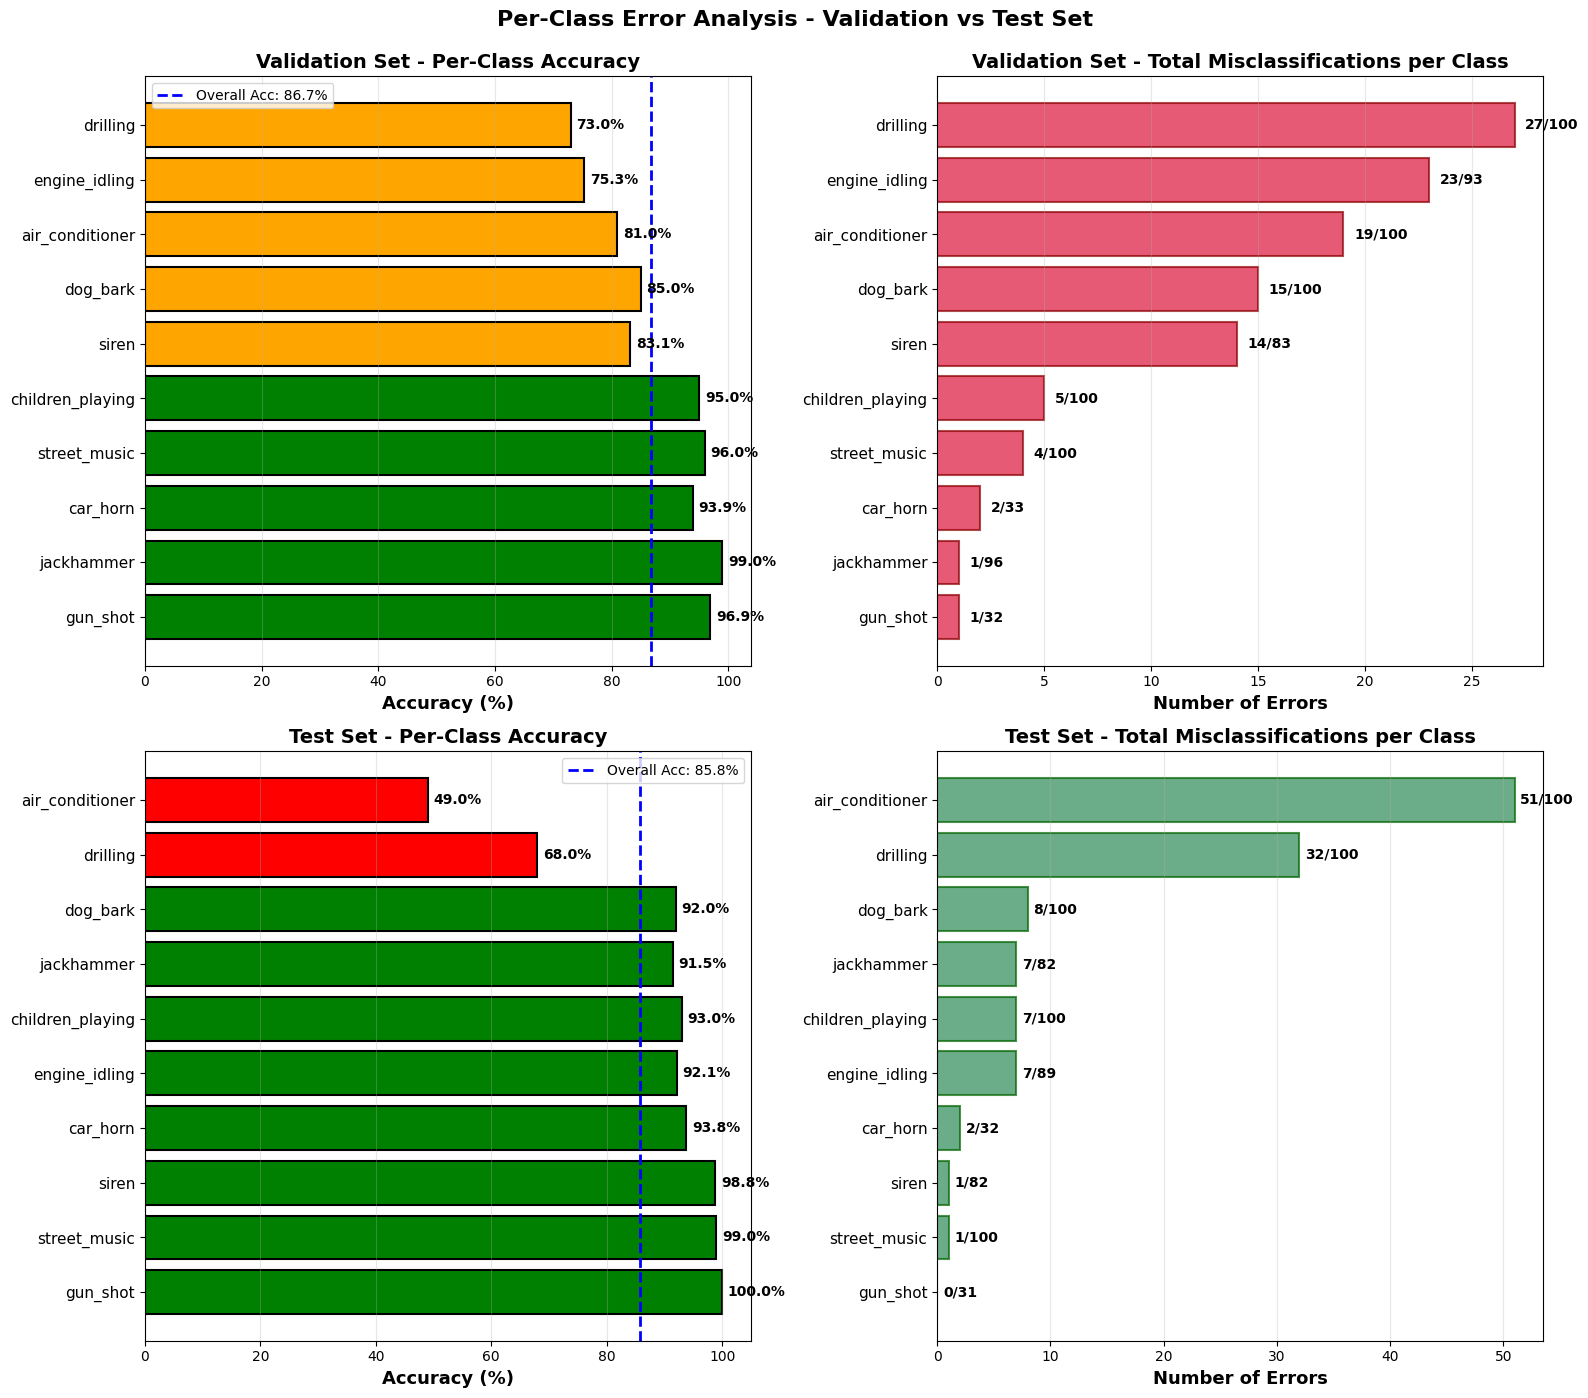

In [14]:
# Function to calculate per-class metrics
def calculate_class_metrics(cm, class_names):
    class_correct = cm.diagonal()
    class_total = cm.sum(axis=1)
    class_errors = class_total - class_correct
    class_accuracy = class_correct / class_total
    
    error_analysis = pd.DataFrame({
        'Class': class_names,
        'Total': class_total,
        'Correct': class_correct,
        'Errors': class_errors,
        'Accuracy': class_accuracy
    })
    error_analysis = error_analysis.sort_values('Errors', ascending=False)
    return error_analysis

# Class names for UrbanSound8K
class_names = [
    'air_conditioner',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'gun_shot',
    'jackhammer',
    'siren',
    'street_music'
]

# Calculate metrics for both sets
error_analysis_val = calculate_class_metrics(ic_val, class_names)
error_analysis_test = calculate_class_metrics(ic_test, class_names)

# Calculate overall accuracies
val_overall_accuracy = np.trace(ic_val) / np.sum(ic_val)
test_overall_accuracy = np.trace(ic_test) / np.sum(ic_test)

# Create figure with 2 rows (validation top, test bottom)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ============= VALIDATION SET (Top Row) =============

# Validation - Accuracy by class
colors_val = ['green' if acc > 0.85 else 'orange' if acc > 0.70 else 'red' 
              for acc in error_analysis_val['Accuracy']]
axes[0, 0].barh(range(len(error_analysis_val)), 
                error_analysis_val['Accuracy'] * 100, 
                color=colors_val, edgecolor='black', linewidth=1.5)
axes[0, 0].set_yticks(range(len(error_analysis_val)))
axes[0, 0].set_yticklabels(error_analysis_val['Class'], fontsize=11)
axes[0, 0].set_xlabel('Accuracy (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Validation Set - Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=val_overall_accuracy*100, color='blue', linestyle='--', 
                   linewidth=2, label=f'Overall Acc: {val_overall_accuracy*100:.1f}%')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_val.iterrows()):
    axes[0, 0].text(row['Accuracy'] * 100 + 1, i, 
                    f"{row['Accuracy']*100:.1f}%", 
                    va='center', fontsize=10, fontweight='bold')

# Validation - Number of errors by class
axes[0, 1].barh(range(len(error_analysis_val)), 
                error_analysis_val['Errors'], 
                color='crimson', edgecolor='darkred', linewidth=1.5, alpha=0.7)
axes[0, 1].set_yticks(range(len(error_analysis_val)))
axes[0, 1].set_yticklabels(error_analysis_val['Class'], fontsize=11)
axes[0, 1].set_xlabel('Number of Errors', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Validation Set - Total Misclassifications per Class', 
                     fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_val.iterrows()):
    axes[0, 1].text(row['Errors'] + 0.5, i, 
                    f"{int(row['Errors'])}/{int(row['Total'])}", 
                    va='center', fontsize=10, fontweight='bold')

# ============= TEST SET (Bottom Row) =============

# Test - Accuracy by class
colors_test = ['green' if acc > 0.85 else 'orange' if acc > 0.70 else 'red' 
               for acc in error_analysis_test['Accuracy']]
axes[1, 0].barh(range(len(error_analysis_test)), 
                error_analysis_test['Accuracy'] * 100, 
                color=colors_test, edgecolor='black', linewidth=1.5)
axes[1, 0].set_yticks(range(len(error_analysis_test)))
axes[1, 0].set_yticklabels(error_analysis_test['Class'], fontsize=11)
axes[1, 0].set_xlabel('Accuracy (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Test Set - Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=test_overall_accuracy*100, color='blue', linestyle='--', 
                   linewidth=2, label=f'Overall Acc: {test_overall_accuracy*100:.1f}%')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_test.iterrows()):
    axes[1, 0].text(row['Accuracy'] * 100 + 1, i, 
                    f"{row['Accuracy']*100:.1f}%", 
                    va='center', fontsize=10, fontweight='bold')

# Test - Number of errors by class
axes[1, 1].barh(range(len(error_analysis_test)), 
                error_analysis_test['Errors'], 
                color='seagreen', edgecolor='darkgreen', linewidth=1.5, alpha=0.7)
axes[1, 1].set_yticks(range(len(error_analysis_test)))
axes[1, 1].set_yticklabels(error_analysis_test['Class'], fontsize=11)
axes[1, 1].set_xlabel('Number of Errors', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Test Set - Total Misclassifications per Class', 
                     fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

for i, (_, row) in enumerate(error_analysis_test.iterrows()):
    axes[1, 1].text(row['Errors'] + 0.5, i, 
                    f"{int(row['Errors'])}/{int(row['Total'])}", 
                    va='center', fontsize=10, fontweight='bold')

plt.suptitle('Per-Class Error Analysis - Validation vs Test Set', 
             fontsize=16, fontweight='bold', y=0.995)
             
plt.tight_layout()
plt.show()